# ESCan ffDTF Envelopes

Starter notebook for envelope-based ffDTF analysis in hyperscanning data.

In [1]:
import os
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

from src.export import load_xarray_from_netcdf, get_export_metadata

In [ ]:
# Paths and scanning settings
export_folder = Path("/Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_EEG_exported")cleaned_signals_folder = Path('../../DATA_film_cleaned/EEG')
TARGET_EVENTS = ['Peppa', 'Brave', 'Incredibles']
# Define analysis electrodes: 
analysis_channels = ['F3',  'Fz','F4', 'C3', 'Cz', 'C4', 'P3','Pz', 'P4']
# Global max frequency for all PSD plots [Hz]
PSD_PLOT_FMAX_HZ = 15.0

# Optional manual exclusion after visual/quality inspection
MANUAL_EXCLUDE_DYADS = ['W_044', 'W_057']  # e.g. ['W_013', 'W_027']

SMOKE_TEST = False  # Set True for quick test run on 2 dyads, False for full run on all valid dyads.
DO_ICA_PREPROCESSING = False  # switch not to repeat ICA preprocessing if already done once, as it is time-consuming. 
                              # Set to True for first run, or change in the hyperparameters,
                              # then switch to False for subsequent runs after ICA components have been saved.

## EEG scan: keep only dyads complete for all TARGET_EVENTS and annotate child group

In [3]:

FILE_RE = re.compile(r'^(W_\d+)_EEG_(ch|cg)_(.+)$')

def discover_role_files(root: Path, target_events):
    files = sorted(p for p in root.rglob('*.nc') if '_EEG_' in p.name)
    pairs = {}
    for p in files:
        m = FILE_RE.match(p.stem)
        if m is None:
            continue
        dyad_id, role, event = m.group(1), m.group(2), m.group(3)
        if event not in target_events:
            continue
        key = (dyad_id, event)
        pairs.setdefault(key, {})[role] = p

    complete = []
    for (dyad_id, event), roles in sorted(pairs.items()):
        if 'ch' in roles and 'cg' in roles:
            complete.append((dyad_id, event, roles['ch'], roles['cg']))
    return complete

pairs_all = discover_role_files(export_folder, TARGET_EVENTS)
if not pairs_all:
    raise FileNotFoundError(f'No complete child/caregiver EEG pairs found in: {export_folder}')

events_required = set(TARGET_EVENTS)
events_by_dyad = {}
for dyad_id, event, _, _ in pairs_all:
    events_by_dyad.setdefault(dyad_id, set()).add(event)

valid_dyads = sorted([
    dyad_id for dyad_id, evs in events_by_dyad.items()
    if events_required.issubset(evs)
])
if MANUAL_EXCLUDE_DYADS:
    valid_dyads = [d for d in valid_dyads if d not in set(MANUAL_EXCLUDE_DYADS)]

# Collect one child-group label per valid dyad (from first TARGET_EVENTS file)
pairs_lookup = {(dyad_id, event): (path_ch, path_cg) for dyad_id, event, path_ch, path_cg in pairs_all}
rows = []
for dyad_id in valid_dyads:
    path_ch, _ = pairs_lookup[(dyad_id, TARGET_EVENTS[0])]
    da_meta = load_xarray_from_netcdf(str(path_ch))
    meta = get_export_metadata(da_meta)
    child_group = meta.get('child_info', {}).get('group', np.nan)
    rows.append({
        'dyadID': dyad_id,
        'child_group': child_group,
        'n_events_present': len(events_by_dyad.get(dyad_id, set())),
    })

valid_dyads_df = pd.DataFrame(rows).sort_values('dyadID').reset_index(drop=True)
valid_pairs = [p for p in pairs_all if p[0] in set(valid_dyads)]

print('EEG scanning summary')
print(f'  Found complete dyad-event pairs (ch+cg): {len(pairs_all)}')
print(f'  Valid dyads with all {len(TARGET_EVENTS)} target events: {len(valid_dyads)}')
print(f'  Valid dyad-event pairs to analyze: {len(valid_pairs)}')
if not valid_dyads_df.empty:
    print('  Child-group counts:')
    print(valid_dyads_df['child_group'].value_counts(dropna=False))

display(valid_dyads_df.head(50))

EEG scanning summary
  Found complete dyad-event pairs (ch+cg): 173
  Valid dyads with all 3 target events: 53
  Valid dyad-event pairs to analyze: 159
  Child-group counts:
child_group
TD                26
ASD               16
P                  7
ASD+P              3
P, możliwe ASD     1
Name: count, dtype: int64


,dyadID,child_group,n_events_present
0,W_000,TD,3
1,W_001,TD,3
2,W_002,TD,3
3,W_003,TD,3
4,W_004,TD,3
5,W_005,TD,3
6,W_009,TD,3
7,W_010,TD,3
8,W_013,TD,3
9,W_014,TD,3


## ICA preprocessing on valid dyads (complete TARGET_EVENTS only)

In [60]:

if DO_ICA_PREPROCESSING:
    from src.ica_preprocessing import ICAPreprocessor



    if 'valid_dyads' not in globals() or len(valid_dyads) == 0:
        raise RuntimeError('valid_dyads is empty. Run the EEG scan cell first.')

    icap = ICAPreprocessor(
        export_folder=export_folder,
        target_events=TARGET_EVENTS,
        valid_dyads=valid_dyads,
    )

    # Set smoke_test=False for full run on all valid dyads.
    icap.find_eeg_files(smoke_test=SMOKE_TEST)

    icap.preprocess_and_save(
        cleaned_signals_folder=cleaned_signals_folder,
        ica_n_components=12,
        ica_max_iter=2000,
        eog_channels=['Fp1', 'Fp2'],
        eog_threshold=3.0,
        clean_muscle=True,
        muscle_l_freq_hz=8.0,
        muscle_threshold=0.4,
        muscle_max_fraction=0.4,
        protect_transients=True,
        transient_zscore_threshold=8.0,
        transient_min_channels=6,
        transient_padding_s=0.15,
        transient_max_fraction=0.15,
        transient_interpolate_output=True,
        save_plots=True,
    )

## PSD overlay (Welch, nperseg=2*fs) for cleaned EEG

Analysis electrodes:
['F3', 'Fz', 'F4', 'C3', 'Cz', 'C4', 'P3', 'Pz', 'P4']


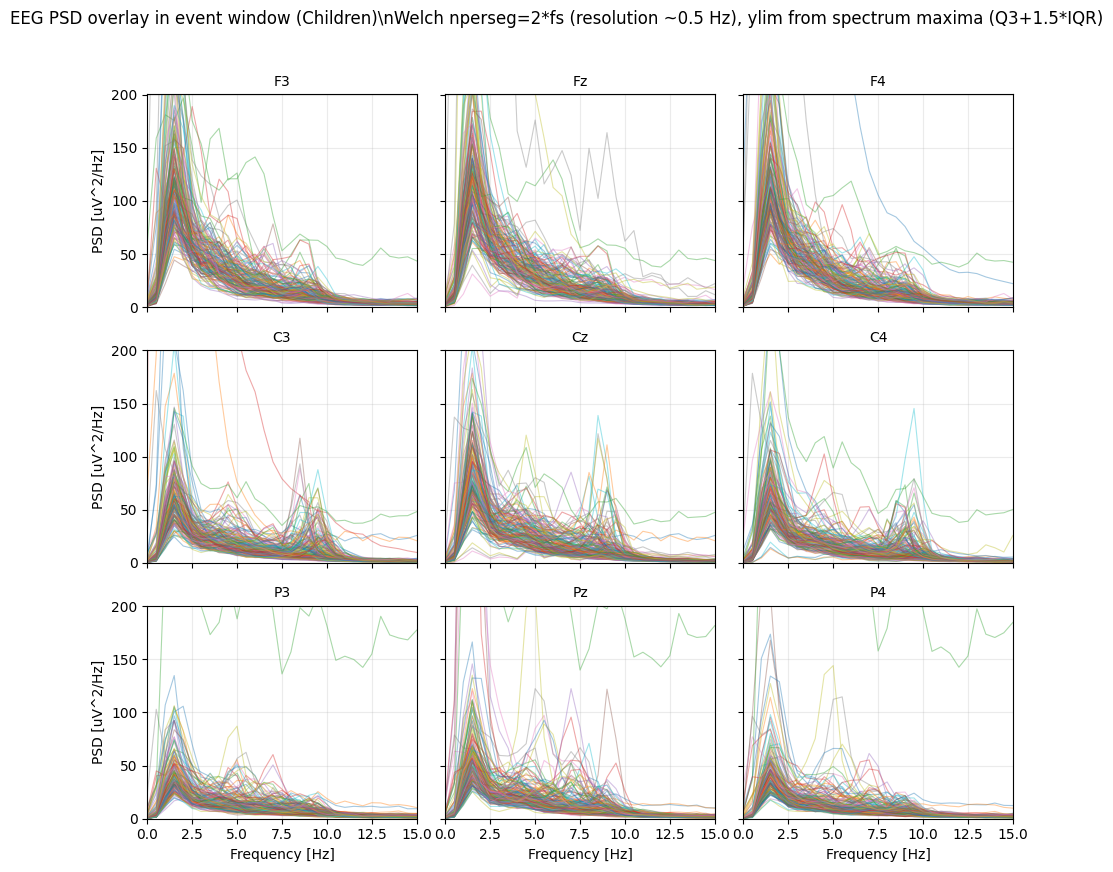

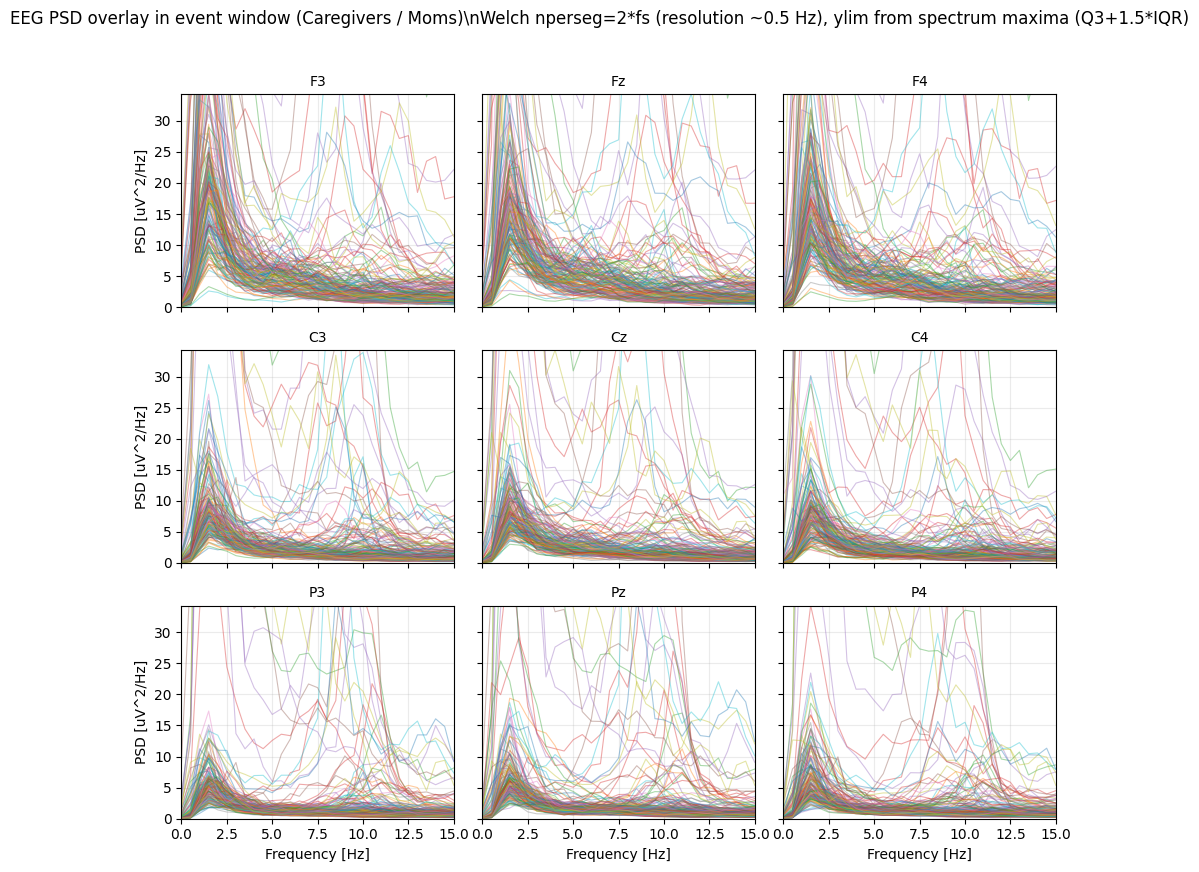

In [4]:
# PSD overlay (Welch, nperseg=2*fs) for cleaned EEG in event window, split by role
from collections import defaultdict
import re
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.signal import welch

CLEAN_RE = re.compile(r'^(W_\d+)_EEG_(ch|cg)_(.+)_cleaned$')

def infer_fs(time_s, attrs):
    fs_attr = attrs.get('sampling_freq', np.nan)
    if np.isfinite(fs_attr) and fs_attr > 0:
        return float(fs_attr)
    if len(time_s) < 2:
        return np.nan
    dt = np.median(np.diff(time_s))
    return float(1.0 / dt) if dt > 0 else np.nan

def get_event_mask(time_s, attrs):
    event_start = float(attrs.get('event_start', 0.0))
    event_duration = float(attrs.get('event_duration', attrs.get('event_duration_s', np.nan)))

    if np.isfinite(event_duration) and event_duration > 0:
        return (time_s >= event_start) & (time_s <= event_start + event_duration)

    # Fallback if metadata is incomplete
    if np.any(time_s >= 0):
        return time_s >= 0
    return np.ones_like(time_s, dtype=bool)

def channel_row(ch_name):
    c = ch_name.upper()
    if c.startswith('F'):
        return 0
    if c.startswith('C'):
        return 1
    if c.startswith('P'):
        return 2
    return None

def channel_col(ch_name):
    c = ch_name.upper()
    if 'Z' in c:
        return 1
    m = re.search(r'(\d+)$', c)
    if m:
        n = int(m.group(1))
        return 0 if n % 2 == 1 else 2
    if c.endswith('L'):
        return 0
    if c.endswith('R'):
        return 2
    return 1

def channel_sort_key(ch_name):
    c = ch_name.upper()
    col = channel_col(c)
    m = re.search(r'(\d+)$', c)
    idx = int(m.group(1)) if m else 999
    return (col, idx, c)

# Gather cleaned files for valid dyads and target events
cleaned_files = []
if 'valid_dyads' in globals():
    valid_dyads_set = set(valid_dyads)
else:
    valid_dyads_set = set()

for p in sorted(cleaned_signals_folder.rglob('*_cleaned.nc')):
    m = CLEAN_RE.match(p.stem)
    if m is None:
        continue
    dyad_id, role, event = m.group(1), m.group(2), m.group(3)
    if event not in TARGET_EVENTS:
        continue
    if valid_dyads_set and dyad_id not in valid_dyads_set:
        continue
    cleaned_files.append((p, dyad_id, role, event))

if not cleaned_files:
    raise FileNotFoundError(f'No cleaned EEG files found in {cleaned_signals_folder} for selected dyads/events.')

# Build PSD container: role -> channel -> list[(freq, psd, event, dyad)]
psd_by_role = {'ch': defaultdict(list), 'cg': defaultdict(list)}
all_channel_sets = []

for p, dyad_id, role, event in cleaned_files:
    with xr.open_dataarray(p) as da:
        time_s = np.asarray(da.coords['time'].values, dtype=float)
        channel_names = [str(ch) for ch in da.coords['channel'].values]
        signal = np.asarray(da.values, dtype=float)  # shape: time x channel
        attrs = dict(da.attrs)

    fs = infer_fs(time_s, attrs)
    if not np.isfinite(fs) or fs <= 0:
        print(f'Skipping {p.name}: invalid sampling frequency.')
        continue

    event_mask = get_event_mask(time_s, attrs)
    if event_mask.sum() < 8:
        print(f'Skipping {p.name}: too few samples in event window.')
        continue

    x_event = signal[event_mask, :]
    all_channel_sets.append(set(channel_names))

    nperseg = int(round(2 * fs))
    nperseg = min(nperseg, x_event.shape[0])
    if nperseg < 8:
        print(f'Skipping {p.name}: segment too short for Welch.')
        continue

    for ci, ch_name in enumerate(channel_names):
        r = channel_row(ch_name)
        if r is None:
            continue
        freqs, pxx = welch(
            x_event[:, ci],
            fs=fs,
            nperseg=nperseg,
            noverlap=nperseg // 2,
            detrend='constant',
            scaling='density',
        )
        psd_by_role[role][ch_name].append((freqs, pxx, event, dyad_id))


print('Analysis electrodes:')
print(analysis_channels)

# Arrange channels in a topography-like grid (rows: F/C/P, cols: L/M/R order)
rows = ['F', 'C', 'P']
row_channels = []
max_cols = 1
for row_idx, row_name in enumerate(rows):
    chs = [ch for ch in analysis_channels if channel_row(ch) == row_idx]
    chs = sorted(chs, key=channel_sort_key)
    row_channels.append(chs)
    max_cols = max(max_cols, len(chs))

def plot_role_overlay(role_key, role_label, fmax=None, alpha=0.4):
    if fmax is None:
        fmax = float(globals().get('PSD_PLOT_FMAX_HZ', 20.0))
    # Robust shared y-limit from per-spectrum maxima: Q3 + 1.5*IQR.
    spectrum_maxima = []
    for ch_name in analysis_channels:
        for freqs, pxx, event, dyad_id in psd_by_role[role_key].get(ch_name, []):
            keep = freqs <= fmax
            vals = pxx[keep]
            vals = vals[np.isfinite(vals)]
            if vals.size:
                spectrum_maxima.append(np.max(vals))

    y = np.asarray(spectrum_maxima, dtype=float)
    y = y[np.isfinite(y)]

    if y.size > 0:
        q1 = np.percentile(y, 25)
        q3 = np.percentile(y, 75)
        iqr = q3 - q1
        ymax = q3 + 1.5 * iqr
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = np.nanmax(y)
    else:
        ymax = 1.0

    if not np.isfinite(ymax) or ymax <= 0:
        ymax = 1.0

    fig, axes = plt.subplots(3, max_cols, figsize=(3.2 * max_cols, 8.5), squeeze=False, sharex=True, sharey=True)
    fig.suptitle(
        f'EEG PSD overlay in event window ({role_label})\\nWelch nperseg=2*fs (resolution ~0.5 Hz), ylim from spectrum maxima (Q3+1.5*IQR)',
        y=1.02,
    )

    for r, row_name in enumerate(rows):
        chs = row_channels[r]
        for c in range(max_cols):
            ax = axes[r, c]
            if c >= len(chs):
                ax.axis('off')
                continue

            ch_name = chs[c]
            traces = psd_by_role[role_key].get(ch_name, [])
            if not traces:
                ax.text(0.5, 0.5, f'{ch_name}\\n(no data)', ha='center', va='center', fontsize=9, transform=ax.transAxes)
                ax.set_xlim(0, fmax)
                ax.set_ylim(0, ymax)
                ax.grid(alpha=0.2)
                continue

            for freqs, pxx, event, dyad_id in traces:
                keep = freqs <= fmax
                ax.plot(freqs[keep], pxx[keep], alpha=alpha, lw=0.8)

            ax.set_title(ch_name, fontsize=10)
            ax.set_xlim(0, fmax)
            ax.set_ylim(0, ymax)
            ax.grid(alpha=0.25)

            if r == 2:
                ax.set_xlabel('Frequency [Hz]')
            if c == 0:
                ax.set_ylabel('PSD [uV^2/Hz]')

    plt.tight_layout()
    plt.show()

plot_role_overlay('ch', 'Children')
plot_role_overlay('cg', 'Caregivers / Moms')

## PSD median for cleaned EEG

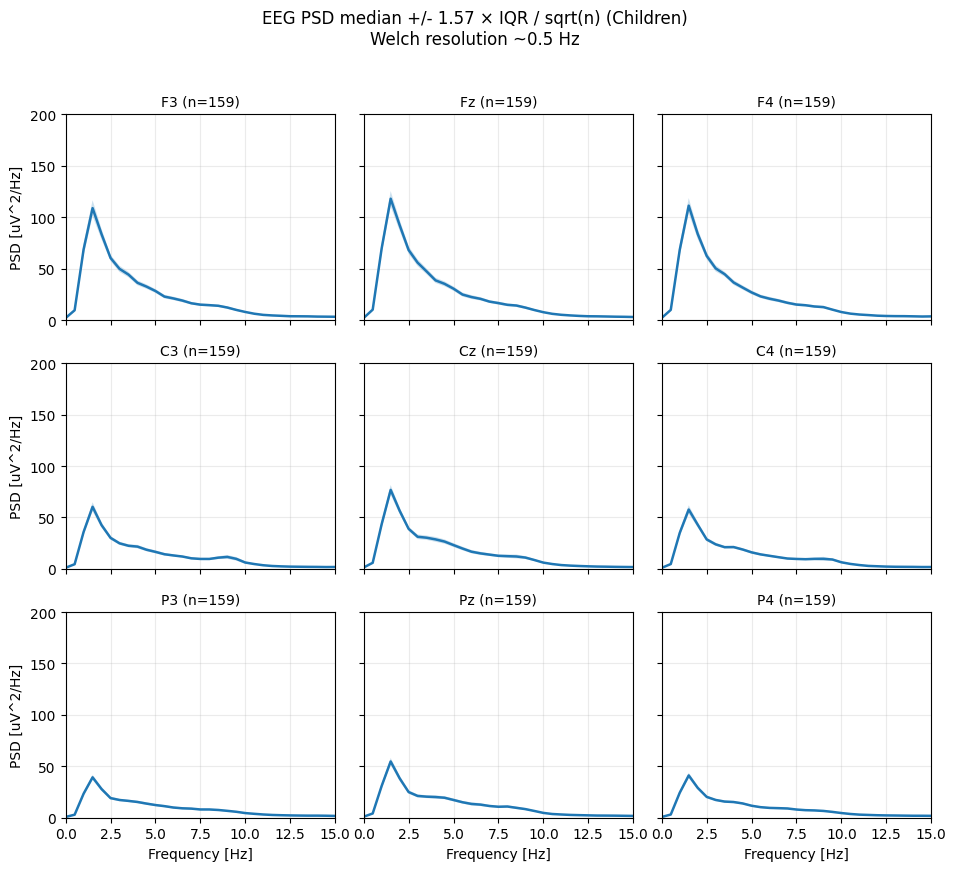

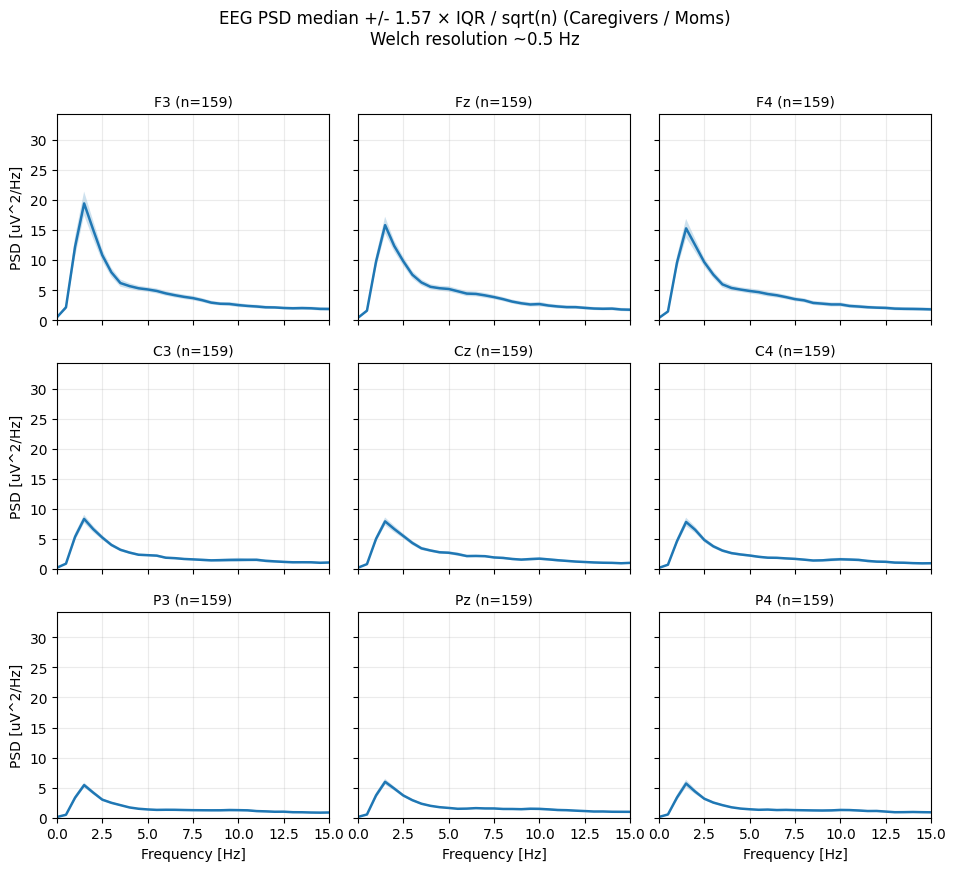

In [5]:
# PSD median +/- notch-style CI in topographic grid (analogous layout, split by role)
import numpy as np
import matplotlib.pyplot as plt

required_vars = ['psd_by_role', 'analysis_channels', 'row_channels', 'max_cols']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'Missing variables from Cell 6: {missing}. Run Cell 6 first.')

def _stack_psd_on_common_freq_notch(traces, fmax):
    """Align spectra to a common frequency grid and return matrix (n_traces x n_freq)."""
    if not traces:
        return None, None

    ref_freqs = None
    ref_len = -1
    for freqs, pxx, event, dyad_id in traces:
        keep = np.isfinite(freqs) & np.isfinite(pxx) & (freqs <= fmax) & (freqs >= 0)
        f = freqs[keep]
        if f.size > ref_len:
            ref_freqs = f
            ref_len = f.size

    if ref_freqs is None or ref_freqs.size < 2:
        return None, None

    stacked = []
    for freqs, pxx, event, dyad_id in traces:
        keep = np.isfinite(freqs) & np.isfinite(pxx) & (freqs <= fmax) & (freqs >= 0)
        f = freqs[keep]
        y = pxx[keep]
        if f.size < 2:
            continue

        y_interp = np.full(ref_freqs.shape, np.nan, dtype=float)
        overlap = (ref_freqs >= f.min()) & (ref_freqs <= f.max())
        if np.any(overlap):
            y_interp[overlap] = np.interp(ref_freqs[overlap], f, y)
        stacked.append(y_interp)

    if not stacked:
        return None, None
    return ref_freqs, np.vstack(stacked)

def _robust_ymax_from_notch(role_key, fmax):
    maxima = []
    for ch_name in analysis_channels:
        for freqs, pxx, event, dyad_id in psd_by_role[role_key].get(ch_name, []):
            keep = np.isfinite(freqs) & np.isfinite(pxx) & (freqs <= fmax) & (freqs >= 0)
            vals = pxx[keep]
            if vals.size:
                maxima.append(np.max(vals))

    y = np.asarray(maxima, dtype=float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return 1.0
    q1 = np.percentile(y, 25)
    q3 = np.percentile(y, 75)
    iqr = q3 - q1
    ymax = q3 + 1.5 * iqr
    if not np.isfinite(ymax) or ymax <= 0:
        ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        ymax = 1.0
    return float(ymax)

def plot_role_median_notch_ci(role_key, role_label, fmax=None, line_lw=1.8, fill_alpha=0.22):
    if fmax is None:
        fmax = float(globals().get('PSD_PLOT_FMAX_HZ', 20.0))
    ymax = _robust_ymax_from_notch(role_key, fmax)

    fig, axes = plt.subplots(3, max_cols, figsize=(3.2 * max_cols, 8.5), squeeze=False, sharex=True, sharey=True)
    fig.suptitle(
        f'EEG PSD median +/- 1.57 × IQR / sqrt(n) ({role_label})\nWelch resolution ~0.5 Hz',
        y=1.02,
    )

    rows_local = ['F', 'C', 'P']
    for r, row_name in enumerate(rows_local):
        chs = row_channels[r]
        for c in range(max_cols):
            ax = axes[r, c]
            if c >= len(chs):
                ax.axis('off')
                continue

            ch_name = chs[c]
            traces = psd_by_role[role_key].get(ch_name, [])
            if not traces:
                ax.text(0.5, 0.5, f'{ch_name}\n(no data)', ha='center', va='center', fontsize=9, transform=ax.transAxes)
                ax.set_xlim(0, fmax)
                ax.set_ylim(0, ymax)
                ax.grid(alpha=0.2)
                continue

            f_ref, mat = _stack_psd_on_common_freq_notch(traces, fmax)
            if f_ref is None or mat is None:
                ax.text(0.5, 0.5, f'{ch_name}\n(insufficient data)', ha='center', va='center', fontsize=9, transform=ax.transAxes)
                ax.set_xlim(0, fmax)
                ax.set_ylim(0, ymax)
                ax.grid(alpha=0.2)
                continue

            med = np.nanmedian(mat, axis=0)
            q1 = np.nanpercentile(mat, 25, axis=0)
            q3 = np.nanpercentile(mat, 75, axis=0)
            iqr = q3 - q1
            n_eff = np.sum(np.isfinite(mat), axis=0)

            ci_half = np.divide(
                1.57 * iqr,
                np.sqrt(np.maximum(n_eff, 1)),
                out=np.full_like(iqr, np.nan),
                where=n_eff > 0,
            )
            lower = np.clip(med - ci_half, a_min=0, a_max=None)
            upper = med + ci_half

            valid = np.isfinite(med)
            ax.plot(f_ref[valid], med[valid], lw=line_lw)
            band = np.isfinite(lower) & np.isfinite(upper)
            if np.any(band):
                ax.fill_between(f_ref[band], lower[band], upper[band], alpha=fill_alpha, linewidth=0)

            ax.set_title(f'{ch_name} (n={len(traces)})', fontsize=10)
            ax.set_xlim(0, fmax)
            ax.set_ylim(0, ymax)
            ax.grid(alpha=0.25)
            if r == 2:
                ax.set_xlabel('Frequency [Hz]')
            if c == 0:
                ax.set_ylabel('PSD [uV^2/Hz]')

    plt.tight_layout()
    plt.show()

plot_role_median_notch_ci('ch', 'Children')
plot_role_median_notch_ci('cg', 'Caregivers / Moms')



# Get the envelopes for selected band

### Extract envelopes

In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from copy import deepcopy
from fractions import Fraction
from scipy.signal import butter, filtfilt, hilbert, welch, resample_poly
from scipy import stats

def extract_band_envelopes(
    da,
    min_f,
    max_f,
    channels,
    downsample_fs_hz=None,
    truncate_to_event_window=False,
    filter_order=4,
    debug=False,
    psd_resolution_hz=0.05,
    welch_overlap=0.5,
):
    """Extract Hilbert envelopes for selected channels in a frequency band.

    The output preserves the input dim ordering of ``da`` after channel selection,
    so if input is (time, channel), output will also be (time, channel).

    Parameters
    ----------
    truncate_to_event_window : bool, default False
        If True, truncate the downsampled envelope to event time only:
        time in [0, event_duration], where event_duration is read from attrs
        ('event_duration' or 'event_duration_s').
    """
    if not isinstance(da, xr.DataArray):
        raise TypeError('da must be an xarray.DataArray')

    channel_dim = 'channel'
    time_dim = 'time'
    if channel_dim not in da.dims or time_dim not in da.dims:
        raise ValueError("da must have dims 'channel' and 'time'")

    if min_f <= 0 or max_f <= min_f:
        raise ValueError('Require 0 < min_f < max_f')
    if not channels:
        raise ValueError('channels list is empty')

    available_channels = da.coords[channel_dim].values
    missing = [ch for ch in channels if ch not in available_channels]
    if missing:
        raise ValueError(f'Channels not found in da: {missing}')

    fs_candidates = ['sampling_freq', 'fs', 'sfreq', 'fs_hz']
    fs = np.nan
    for key in fs_candidates:
        val = da.attrs.get(key, np.nan)
        if np.isfinite(val) and float(val) > 0:
            fs = float(val)
            break
    if not np.isfinite(fs) or fs <= 0:
        raise ValueError(
            "Sampling frequency not found in attrs. Expected one of: "
            f"{fs_candidates}"
        )

    da_sel = da.sel({channel_dim: channels})
    original_dims = tuple(da_sel.dims)

    # Process in channel x time order, then transpose back to original ordering.
    da_proc = da_sel.transpose(channel_dim, time_dim)
    x = np.asarray(da_proc.values, dtype=float)  # shape: (n_channels, n_time)

    time_vals = np.asarray(da_proc.coords[time_dim].values, dtype=float)
    if time_vals.size < 3:
        raise ValueError('Need at least 3 time points')

    nyq = fs / 2.0
    if max_f >= nyq:
        raise ValueError(f'max_f ({max_f:.3f} Hz) must be < Nyquist ({nyq:.3f} Hz)')

    wn = [min_f / nyq, max_f / nyq]
    b, a = butter(filter_order, wn, btype='bandpass')

    env = np.full_like(x, np.nan, dtype=float)
    for ci in range(x.shape[0]):
        sig = x[ci, :]
        finite = np.isfinite(sig)
        if not np.any(finite):
            continue

        sig_work = sig.copy()
        if not np.all(finite):
            idx = np.arange(sig.size)
            sig_work[~finite] = np.interp(idx[~finite], idx[finite], sig[finite])

        bp = filtfilt(b, a, sig_work, axis=-1)
        amp = np.abs(hilbert(bp, axis=-1))
        env[ci, :] = amp

    fs_out = fs
    t_out = time_vals

    if downsample_fs_hz is not None:
        downsample_fs_hz = float(downsample_fs_hz)
        if not np.isfinite(downsample_fs_hz) or downsample_fs_hz <= 0:
            raise ValueError('downsample_fs_hz must be a positive finite number')
        if downsample_fs_hz > fs:
            raise ValueError('downsample_fs_hz must be <= input sampling frequency')

        if downsample_fs_hz < fs:
            ratio = Fraction(downsample_fs_hz / fs).limit_denominator(1000)
            env = resample_poly(env, up=ratio.numerator, down=ratio.denominator, axis=1)
            fs_out = fs * ratio.numerator / ratio.denominator
            t0 = float(time_vals[0])
            t_out = t0 + np.arange(env.shape[1], dtype=float) / fs_out

    if truncate_to_event_window:
        ev_dur = da.attrs.get('event_duration', da.attrs.get('event_duration_s', np.nan))
        try:
            ev_dur = float(ev_dur)
        except Exception:
            ev_dur = np.nan
        if not np.isfinite(ev_dur) or ev_dur <= 0:
            raise ValueError(
                'truncate_to_event_window=True requires positive event duration in attrs: '
                "event_duration or event_duration_s"
            )

        keep = (t_out >= 0.0) & (t_out <= ev_dur)
        if not np.any(keep):
            raise ValueError(
                f'No samples remain after truncation to [0, {ev_dur}] s. '
                'Check time coordinates and event metadata.'
            )
        env = env[:, keep]
        t_out = t_out[keep]

    env = stats.zscore(env, axis=1, nan_policy='omit')

    env_proc = xr.DataArray(
        env,
        dims=(channel_dim, time_dim),
        coords={channel_dim: da_proc.coords[channel_dim].values, time_dim: t_out},
        attrs={
            'band_min_f_hz': float(min_f),
            'band_max_f_hz': float(max_f),
            'fs_hz': float(fs_out),
            'source_fs_hz': float(fs),
            'method': 'bandpass_butter_hilbert_amplitude_zscore',
        },
    )

    if downsample_fs_hz is not None:
        env_proc.attrs['requested_downsample_fs_hz'] = float(downsample_fs_hz)
    env_proc.attrs['truncate_to_event_window'] = int(bool(truncate_to_event_window))

    if truncate_to_event_window:
        env_proc.attrs['event_window_start_s'] = 0.0
        env_proc.attrs['event_window_end_s'] = float(t_out[-1])

    if 'child_info' in da.attrs:
        env_proc.attrs['child_info'] = deepcopy(da.attrs['child_info'])

    env_da = env_proc.transpose(*original_dims)

    if debug:
        n_ch = env_proc.sizes[channel_dim]
        fig, axes = plt.subplots(n_ch, 2, figsize=(12, max(2.5 * n_ch, 4.0)), squeeze=False)

        nperseg = int(round(fs_out / psd_resolution_hz))
        nperseg = max(8, min(nperseg, env_proc.sizes[time_dim]))
        noverlap = int(round(welch_overlap * nperseg))
        noverlap = min(max(0, noverlap), nperseg - 1)

        for i, ch in enumerate(env_proc.coords[channel_dim].values):
            y = np.asarray(env_proc.sel({channel_dim: ch}).values, dtype=float)
            t = np.asarray(env_proc.coords[time_dim].values, dtype=float)

            ax_t = axes[i, 0]
            ax_t.plot(t, y, lw=1.0)
            ax_t.set_title(f'{ch} envelope (z-scored)')
            ax_t.set_xlabel('Time [s]')
            ax_t.set_ylabel('Amplitude')
            ax_t.grid(alpha=0.3)

            ax_p = axes[i, 1]
            good = np.isfinite(y)
            if np.sum(good) >= 8:
                f, pxx = welch(y[good], fs=fs_out, nperseg=nperseg, noverlap=noverlap)
                ax_p.plot(f, pxx, lw=1.2)
            else:
                ax_p.text(0.5, 0.5, 'insufficient data', ha='center', va='center', transform=ax_p.transAxes)

            ax_p.set_title(f'{ch} envelope PSD (Welch, df~{psd_resolution_hz:.2f} Hz)')
            ax_p.set_xlabel('Frequency [Hz]')
            ax_p.set_ylabel('PSD')
            ax_p.set_xlim((0, fs_out / 2))
            ax_p.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return env_da


# Example usage:
# env_alpha = extract_band_envelopes(
#     da, 8.0, 12.0, ['Fz', 'Cz', 'Pz'],
#     downsample_fs_hz=20.0, truncate_to_event_window=True, debug=True
# )
# env_alpha

In [7]:
# Smoke test: run on one available cleaned EEG file and verify output.
RUN_EXTRACT_BAND_ENVELOPES_SMOKE_TEST = False

if RUN_EXTRACT_BAND_ENVELOPES_SMOKE_TEST:
    smoke_path = '/Users/admin/Documents/Hoza/PROJEKTY/SYNCC_IN_LOCAL_HOME/DATA_film_cleaned/EEG/W_000/W_000_EEG_cg_Brave_cleaned.nc'
    with xr.open_dataarray(smoke_path) as _da_in:
        da_smoke = _da_in.load()

    print(f'data shape: {da_smoke.shape}, dims: {da_smoke.dims}, coords: {list(da_smoke.coords)}')

    preferred = analysis_channels if 'analysis_channels' in globals() else ['Fz', 'Cz', 'Pz']
    available = [str(ch) for ch in da_smoke.coords['channel'].values]
    smoke_channels = [ch for ch in preferred if ch in available]
    if len(smoke_channels) < 3:
        smoke_channels = available[: min(3, len(available))]

    band_lo = 4.0
    band_hi = 8.0
    env_candidate = extract_band_envelopes(
        da=da_smoke,
        min_f=band_lo,
        max_f=band_hi,
        channels=smoke_channels,
        downsample_fs_hz=8.0,
        filter_order=4,
        debug=True,
    )

    print(f'output shape: {env_candidate.shape}')
    print(f"output fs_hz: {env_candidate.attrs.get('fs_hz')}")
    print(f"source fs_hz: {env_candidate.attrs.get('source_fs_hz')}")

### ffDTF Envelopes: Setup and Configuration
Defines analysis parameters for envelope extraction, ffDTF frequency ranges, model-order settings, and surrogate options.

In [38]:
# Envelope-based ffDTF batch for real and surrogate dyads (analogous to ESCan_ffdtf_batch)
from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.mtmvar import mvar_criterion, full_freq_dtf, multivariate_spectra

# ----------------------------
# Configuration
# ----------------------------
ENVELOPE_MIN_F = 7.5 #8.0
ENVELOPE_MAX_F =13.0 #13.0

ENVELOPE_DOWNSAMPLE_FS_HZ = 16.0  # 8 Hz made AIC collapse to p=1 in diagnostics; 12 Hz restored p~5
ENVELOPE_TRUNCATE_TO_EVENT_WINDOW = True

MAX_MODEL_ORDER = 20
OPTIMAL_MODEL_ORDER = 5# None  # set int to force fixed order
CRIT_TYPE = 'AIC'
PLOT_CRIT = False

FREQ_MIN = 0.1
FREQ_MAX = 5.0
FREQ_STEP = 0.1
SUM_FREQ_MIN = 0.5
SUM_FREQ_MAX = 3.0

# Optional transform applied to ffDTF sums before saving to ff_dtf.
# Useful when edge distributions are closer to log-normal than normal.
# Options: 'none', 'log', 'log1p', 'sqrt'
FFDTF_SUM_TRANSFORM = 'sqrt'  # 'none', 'log', 'log1p', or 'sqrt'
FFDTF_SUM_TRANSFORM_EPS = 1e-9

KEEP_ONLY_CROSS_PERSON = True

INCLUDE_SURROGATES = True
SURROGATE_RANDOM_SEED = 42
SURROGATE_USE_ALL = False
SURROGATE_SUBSET_SIZE = 50

# If SMOKE_TEST is True in this notebook, keep computation small.
PROCESS_ONLY_SMOKE_DYADS = False
SMOKE_MAX_REAL_DYADS = 4

# Optional ffDTF debug plotting
DEBUG_PLOT_FF_DTF = False # Set True to enable ffDTF spectrum plotting for dyad-event pairs, which can be very time-consuming. 
                          # Consider also setting PROCESS_ONLY_SMOKE_DYADS=True and/or adjusting SMOKE_MAX_REAL_DYADS to limit the number of spectra plotted.
DEBUG_PLOT_FF_DTF_ONLY_CROSS = True # If True, only plot ffDTF spectra for cross-person direction (e.g. child->caregiver), 
                                    # which are typically of most interest, to reduce number of plots and runtime.
DEBUG_PLOT_FF_DTF_GRID = False
DEBUG_PLOT_FF_DTF_GRID_MAX_CH = 24
DEBUG_PLOT_FF_DTF_MAX_JOBS = SMOKE_MAX_REAL_DYADS*3  # limit total number of ffDTF spectra plotted across all dyads/events to avoid excessive runtime in smoke test.



CLEAN_RE = re.compile(r'^(W_\d+)_EEG_(ch|cg)_(.+)_cleaned$')

# Runtime counter limiting number of dyad-event debug plotting calls.
_ffdtf_plot_state = {'n_plotted': 0}

print('Cell 15 setup loaded.')

Cell 15 setup loaded.


### ffDTF Envelopes: Helper Functions
Contains channel selection, z-scoring, robust group extraction, and pair-level ffDTF computation helpers.

In [9]:
# Helper functions

def _select_common_channels(ch_child, ch_caregiver, preferred=None):
    c1 = set(map(str, ch_child))
    c2 = set(map(str, ch_caregiver))
    common = c1 & c2
    if preferred is None:
        return sorted(common)
    ordered = [ch for ch in preferred if ch in common]
    return ordered


def _debug_plot_ffdtf_grid(freqs, ff_dtf, spectra, node_names, dyad_id, event, pair_type):
    ff_abs = np.abs(ff_dtf)
    sp_abs = np.abs(spectra)
    n_nodes = ff_abs.shape[0]

    max_off = np.nanmax(ff_abs) if np.isfinite(np.nanmax(ff_abs)) else 1.0
    max_diag = np.nanmax(np.diagonal(sp_abs, axis1=0, axis2=1))
    if not np.isfinite(max_off) or max_off <= 0:
        max_off = 1.0
    if not np.isfinite(max_diag) or max_diag <= 0:
        max_diag = 1.0

    fig, axs = plt.subplots(
        n_nodes, n_nodes,
        figsize=(max(8, n_nodes * 0.8), max(8, n_nodes * 0.8)),
        gridspec_kw={'wspace': 0, 'hspace': 0},
    )

    for i in range(n_nodes):
        for j in range(n_nodes):
            ax = axs[i, j] if n_nodes > 1 else axs
            if i != j:
                y = np.real(ff_abs[i, j, :])
                ax.plot(freqs, y, lw=0.5)
                ax.fill_between(freqs, y, 0, color='skyblue', alpha=0.4)
                ax.set_ylim([0, max_off])
            else:
                y = np.real(sp_abs[i, i, :])
                ax.plot(freqs, y, lw=0.5, color=[0.7, 0.7, 0.7])
                ax.fill_between(freqs, y, 0, color=[0.7, 0.7, 0.7], alpha=0.4)
                ax.set_ylim([0, max_diag])

            ax.tick_params(
                labelleft=(j == 0),
                labelbottom=(i == n_nodes - 1),
                left=(j == 0),
                bottom=(i == n_nodes - 1),
                labelsize=4,
            )
            ax.tick_params(axis='x', labelsize=6)
            if i == n_nodes - 1:
                ax.set_xlabel(node_names[j], fontsize=8)
            if j == 0:
                ax.set_ylabel(node_names[i], fontsize=8)

    fig.suptitle(
        f'ffDTF(freq) + spectra(diag) | {dyad_id} | {event} | {pair_type}',
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()


def _debug_plot_ffdtf_sum_matrix(ff_dtf_sum, node_names, use_channels, dyad_id, event, pair_type):
    plot_mat = ff_dtf_sum.copy()
    np.fill_diagonal(plot_mat, np.nan)

    if DEBUG_PLOT_FF_DTF_ONLY_CROSS:
        n_ch = len(use_channels)
        mask = np.zeros_like(plot_mat, dtype=bool)
        mask[:n_ch, n_ch:] = True
        mask[n_ch:, :n_ch] = True
        plot_mat = np.where(mask, plot_mat, np.nan)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(plot_mat, cmap='viridis', aspect='auto')
    ax.set_title(f'ffDTF sum ({SUM_FREQ_MIN:g}-{SUM_FREQ_MAX:g} Hz) | {dyad_id} | {event} | {pair_type}')
    ticks = np.arange(len(node_names))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(node_names, rotation=90, fontsize=6)
    ax.set_yticklabels(node_names, fontsize=6)
    ax.set_xlabel('Source channel')
    ax.set_ylabel('Target channel')
    fig.colorbar(im, ax=ax, label='Summed ffDTF')
    plt.tight_layout()
    plt.show()


def _extract_group_from_child_da(da_child):
    grp = np.nan

    child_info_attr = da_child.attrs.get('child_info', np.nan)
    if isinstance(child_info_attr, dict):
        grp = child_info_attr.get('group', np.nan)
    elif isinstance(child_info_attr, str) and child_info_attr.strip():
        try:
            decoded = json.loads(child_info_attr)
            if isinstance(decoded, dict):
                grp = decoded.get('group', np.nan)
        except Exception:
            pass

    if (isinstance(grp, str) and grp.strip() == '') or pd.isna(grp):
        meta = get_export_metadata(da_child)
        grp = meta.get('child_info', {}).get('group', np.nan)

    if (isinstance(grp, str) and grp.strip() == '') or pd.isna(grp):
        dyad = da_child.attrs.get('dyad_id', np.nan)
        if 'valid_dyads_df' in globals() and isinstance(dyad, str) and not valid_dyads_df.empty:
            row = valid_dyads_df.loc[valid_dyads_df['dyadID'] == dyad, 'child_group']
            if len(row) > 0:
                grp = row.iloc[0]

    if isinstance(grp, str) and grp.strip() == '':
        grp = np.nan
    return grp


def compute_pair_ffdtf_rows_from_envelopes(
    path_child: Path,
    path_caregiver: Path,
    dyad_id: str,
    event: str,
    pair_type: str,
    surrogate_pair_id=None,
    surrogate_caregiver_dyad=None,
    surrogate_child_dyad=None,
):
    da_ch = load_xarray_from_netcdf(str(path_child))
    da_cg = load_xarray_from_netcdf(str(path_caregiver))

    env_ch = extract_band_envelopes(
        da=da_ch,
        min_f=ENVELOPE_MIN_F,
        max_f=ENVELOPE_MAX_F,
        channels=[str(ch) for ch in da_ch.coords['channel'].values],
        downsample_fs_hz=ENVELOPE_DOWNSAMPLE_FS_HZ,
        truncate_to_event_window=ENVELOPE_TRUNCATE_TO_EVENT_WINDOW,
        filter_order=4,
        debug=False,
    )
    env_cg = extract_band_envelopes(
        da=da_cg,
        min_f=ENVELOPE_MIN_F,
        max_f=ENVELOPE_MAX_F,
        channels=[str(ch) for ch in da_cg.coords['channel'].values],
        downsample_fs_hz=ENVELOPE_DOWNSAMPLE_FS_HZ,
        truncate_to_event_window=ENVELOPE_TRUNCATE_TO_EVENT_WINDOW,
        filter_order=4,
        debug=False,
    )

    fs_ch = float(env_ch.attrs.get('fs_hz', np.nan))
    fs_cg = float(env_cg.attrs.get('fs_hz', np.nan))
    if not np.isfinite(fs_ch) or not np.isfinite(fs_cg):
        raise ValueError(f'Envelope fs_hz missing for {dyad_id}/{event}')
    if not np.isclose(fs_ch, fs_cg):
        raise ValueError(f'Envelope fs mismatch for {dyad_id}/{event}: child={fs_ch}, caregiver={fs_cg}')

    nyq_env = 0.5 * float(fs_ch)
    if float(FREQ_MAX) >= nyq_env:
        raise ValueError(
            f'FREQ_MAX ({FREQ_MAX}) must be < envelope Nyquist ({nyq_env:.3f} Hz). '
            f'Increase ENVELOPE_DOWNSAMPLE_FS_HZ or lower FREQ_MAX.'
        )

    preferred_channels = globals().get('analysis_channels', None)
    use_channels = _select_common_channels(
        env_ch.coords['channel'].values,
        env_cg.coords['channel'].values,
        preferred=preferred_channels,
    )
    if len(use_channels) == 0:
        raise ValueError(f'No common channels in envelopes for {dyad_id}/{event}')

    # Build channel system explicitly as (n_channels, n_time) for MVAR/ffDTF.
    sig_ch = np.asarray(
        env_ch.sel(channel=use_channels).transpose('channel', 'time').values,
        dtype=float,
    )
    sig_cg = np.asarray(
        env_cg.sel(channel=use_channels).transpose('channel', 'time').values,
        dtype=float,
    )

    if sig_ch.ndim != 2 or sig_cg.ndim != 2:
        raise ValueError(
            f'Envelope arrays must be 2D after channel/time selection. '
            f'Got child={sig_ch.shape}, caregiver={sig_cg.shape}'
        )

    n_samp = min(sig_ch.shape[1], sig_cg.shape[1])
    if n_samp < 50:
        raise ValueError(f'Too few samples after envelope extraction for {dyad_id}/{event}: {n_samp}')
    sig_ch = sig_ch[:, :n_samp]
    sig_cg = sig_cg[:, :n_samp]

    # Concatenate along channel axis: [child_channels; caregiver_channels].
    signals_joint = np.concatenate([sig_ch, sig_cg], axis=0)
    expected_shape = (2 * len(use_channels), n_samp)
    if signals_joint.shape != expected_shape:
        raise ValueError(
            f'Unexpected joint system shape for {dyad_id}/{event}: '
            f'got {signals_joint.shape}, expected {expected_shape} '
            '(n_nodes, n_time)'
        )

    node_names = [f'ch:{ch}' for ch in use_channels] + [f'cg:{ch}' for ch in use_channels]

    freqs = np.arange(FREQ_MIN, FREQ_MAX + FREQ_STEP * 0.5, FREQ_STEP)
    band_mask = (freqs >= SUM_FREQ_MIN) & (freqs <= SUM_FREQ_MAX)
    if not np.any(band_mask):
        raise ValueError('Selected summation band does not overlap ffDTF frequency grid')

    if OPTIMAL_MODEL_ORDER is None:
        _, _, p_opt = mvar_criterion(signals_joint, MAX_MODEL_ORDER, CRIT_TYPE, plot=PLOT_CRIT)
    else:
        p_opt = int(OPTIMAL_MODEL_ORDER)

    ff_dtf = full_freq_dtf(
        signals_joint,
        freqs=freqs,
        fs=float(fs_ch),
        max_model_order=MAX_MODEL_ORDER,
        optimal_model_order=p_opt,
        crit_type=CRIT_TYPE,
    )

    do_debug = bool(DEBUG_PLOT_FF_DTF or DEBUG_PLOT_FF_DTF_GRID)
    if do_debug and (_ffdtf_plot_state.get('n_plotted', 0) < int(DEBUG_PLOT_FF_DTF_MAX_JOBS)):
        if DEBUG_PLOT_FF_DTF_GRID and len(node_names) <= int(DEBUG_PLOT_FF_DTF_GRID_MAX_CH):
            spectra = multivariate_spectra(
                signals_joint,
                freqs=freqs,
                fs=float(fs_ch),
                max_model_order=MAX_MODEL_ORDER,
                optimal_model_order=p_opt,
                crit_type=CRIT_TYPE,
            )
            _debug_plot_ffdtf_grid(freqs, ff_dtf, spectra, node_names, dyad_id, event, pair_type)

    ff_dtf_sum = ff_dtf[:, :, band_mask].sum(axis=2)

    # Optional variance-stabilizing transform for summed ffDTF values.
    ffdtf_transform = str(globals().get('FFDTF_SUM_TRANSFORM', 'none')).strip().lower()
    ffdtf_eps = float(globals().get('FFDTF_SUM_TRANSFORM_EPS', 1e-9))
    if ffdtf_transform not in {'none', 'log', 'log1p', 'sqrt'}:
        raise ValueError(
            f'Unsupported FFDTF_SUM_TRANSFORM={ffdtf_transform!r}. '
            "Use one of: 'none', 'log', 'log1p', 'sqrt'."
        )
    if ffdtf_transform == 'log':
        ff_dtf_sum = np.log(np.maximum(ff_dtf_sum, 0.0) + ffdtf_eps)
    elif ffdtf_transform == 'log1p':
        ff_dtf_sum = np.log1p(np.maximum(ff_dtf_sum, 0.0))
    elif ffdtf_transform == 'sqrt':
        ff_dtf_sum = np.sqrt(ff_dtf_sum)

    if do_debug and (_ffdtf_plot_state.get('n_plotted', 0) < int(DEBUG_PLOT_FF_DTF_MAX_JOBS)):
        if DEBUG_PLOT_FF_DTF:
            _debug_plot_ffdtf_sum_matrix(ff_dtf_sum, node_names, use_channels, dyad_id, event, pair_type)
        _ffdtf_plot_state['n_plotted'] = _ffdtf_plot_state.get('n_plotted', 0) + 1

    group = _extract_group_from_child_da(da_ch)

    if surrogate_pair_id is None:
        surrogate_pair_id = dyad_id
    if surrogate_caregiver_dyad is None:
        surrogate_caregiver_dyad = dyad_id
    if surrogate_child_dyad is None:
        surrogate_child_dyad = dyad_id

    rows = []
    n_nodes = len(node_names)
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i == j:
                continue
            src = node_names[j]
            dst = node_names[i]
            edge_type = 'cross-brain' if src.split(':')[0] != dst.split(':')[0] else 'intra-brain'
            if KEEP_ONLY_CROSS_PERSON and edge_type == 'intra-brain':
                continue

            rows.append({
                'dyadID': dyad_id,
                'surrogate_pair_id': surrogate_pair_id,
                'surrogate_caregiver_dyad': surrogate_caregiver_dyad,
                'surrogate_child_dyad': surrogate_child_dyad,
                'pair_type': pair_type,
                'channel_pair': f'{src}->{dst}',
                'edge_type': edge_type,
                'ff_dtf': float(ff_dtf_sum[i, j]),
                'group': group,
                'event': event,
                'n_channels_per_person': int(len(use_channels)),
                'model_order': int(p_opt),
            })

    dbg = {
        'dyadID': dyad_id,
        'event': event,
        'pair_type': pair_type,
        'n_channels_per_person': len(use_channels),
        'n_time_samples': int(n_samp),
        'joint_shape': tuple(signals_joint.shape),
        'p_opt': int(p_opt),
        'n_rows': len(rows),
        'ffdtf_sum_transform': ffdtf_transform,
    }
    return rows, dbg

print('Cell 16 helpers loaded.')

Cell 16 helpers loaded.


### ffDTF Envelopes: Build Real and Surrogate Pairs
Builds complete child-caregiver real pairs and surrogate pair definitions from cleaned files and target events.

In [39]:
# Build real and surrogate pair lists from cleaned ICA files
all_cleaned = []
for p in sorted(Path(cleaned_signals_folder).rglob('*_cleaned.nc')):
    m = CLEAN_RE.match(p.stem)
    if m is None:
        continue
    dyad_id, role, event = m.group(1), m.group(2), m.group(3)
    if event not in TARGET_EVENTS:
        continue
    all_cleaned.append((dyad_id, event, role, p))

pair_lookup = {}
for dyad_id, event, role, p in all_cleaned:
    pair_lookup.setdefault((dyad_id, event), {})[role] = p

real_pairs_all = []
for (dyad_id, event), roles in sorted(pair_lookup.items()):
    if 'ch' in roles and 'cg' in roles:
        real_pairs_all.append((dyad_id, event, roles['ch'], roles['cg']))

if 'valid_dyads' in globals() and len(valid_dyads) > 0:
    valid_set = set(valid_dyads)
    real_pairs_all = [x for x in real_pairs_all if x[0] in valid_set]

if PROCESS_ONLY_SMOKE_DYADS:
    keep_dyads = sorted({d for d, _, _, _ in real_pairs_all})[:SMOKE_MAX_REAL_DYADS]
    keep_set = set(keep_dyads)
    real_pairs_all = [x for x in real_pairs_all if x[0] in keep_set]

if not real_pairs_all:
    raise RuntimeError('No real cleaned dyad/event pairs available for envelope ffDTF.')

print(f'Real dyad-event pairs to process: {len(real_pairs_all)}')

rng = np.random.default_rng(SURROGATE_RANDOM_SEED)
dyads_real = sorted({d for d, _, _, _ in real_pairs_all})
all_surrogate_dyads = [
    (dyad_cg, dyad_ch)
    for dyad_cg in dyads_real
    for dyad_ch in dyads_real
    if dyad_cg != dyad_ch
]

selected_surrogate_dyads = []
if INCLUDE_SURROGATES and all_surrogate_dyads:
    if SURROGATE_USE_ALL:
        selected_surrogate_dyads = list(all_surrogate_dyads)
    else:
        # Pick N random caregivers per child dyad to ensure full coverage
        SURROGATES_PER_CHILD = 3
        selected_surrogate_dyads = []
        for child_dyad in dyads_real:
            candidates = [
                (dyad_cg, dyad_ch)
                for dyad_cg, dyad_ch in all_surrogate_dyads
                if dyad_ch == child_dyad
            ]
            n_pick = min(SURROGATES_PER_CHILD, len(candidates))
            if n_pick == 0:
                continue
            idx = rng.choice(len(candidates), size=n_pick, replace=False)
            selected_surrogate_dyads.extend([candidates[i] for i in idx])

surrogate_pairs = []
for dyad_cg, dyad_ch in selected_surrogate_dyads:
    surrogate_id = f'S_{dyad_cg}_cg__{dyad_ch}_ch'
    for event in TARGET_EVENTS:
        key_ch = (dyad_ch, event)
        key_cg = (dyad_cg, event)
        if key_ch not in pair_lookup or key_cg not in pair_lookup:
            continue
        roles_ch = pair_lookup[key_ch]
        roles_cg = pair_lookup[key_cg]
        if ('ch' in roles_ch) and ('cg' in roles_cg):
            surrogate_pairs.append((surrogate_id, event, roles_ch['ch'], roles_cg['cg'], dyad_cg, dyad_ch))

print(f'Selected surrogate caregiver-child dyads: {len(selected_surrogate_dyads)}')
print(f'Surrogate dyad-event pairs to process: {len(surrogate_pairs)}')
print('Cell 17 pair lists built.')

Real dyad-event pairs to process: 159
Selected surrogate caregiver-child dyads: 159
Surrogate dyad-event pairs to process: 477
Cell 17 pair lists built.


### ffDTF Envelopes: Run Batch and Summarize
Runs real and surrogate computations, assembles output dataframes, and prints summary diagnostics.

In [40]:
# Compute ffDTF rows for real and surrogate pairs, then assemble outputs
all_rows = []
debug_rows = []
failed = []

# Reset plotting counter for each batch run.
_ffdtf_plot_state = {'n_plotted': 0}

for dyad_id, event, path_ch, path_cg in real_pairs_all:
    print(f'Processing REAL {dyad_id} | {event}')
    try:
        rows, dbg = compute_pair_ffdtf_rows_from_envelopes(
            path_child=path_ch,
            path_caregiver=path_cg,
            dyad_id=dyad_id,
            event=event,
            pair_type='real',
            surrogate_pair_id=dyad_id,
            surrogate_caregiver_dyad=dyad_id,
            surrogate_child_dyad=dyad_id,
        )
        all_rows.extend(rows)
        debug_rows.append(dbg)
    except Exception as exc:
        failed.append({'dyadID': dyad_id, 'event': event, 'pair_type': 'real', 'error': str(exc)})

for surrogate_id, event, path_ch, path_cg, dyad_cg, dyad_ch in surrogate_pairs:
    print(f'Processing SURROGATE {surrogate_id} | {event}')
    try:
        rows, dbg = compute_pair_ffdtf_rows_from_envelopes(
            path_child=path_ch,
            path_caregiver=path_cg,
            dyad_id=surrogate_id,
            event=event,
            pair_type='surrogate',
            surrogate_pair_id=surrogate_id,
            surrogate_caregiver_dyad=dyad_cg,
            surrogate_child_dyad=dyad_ch,
        )
        all_rows.extend(rows)
        debug_rows.append(dbg)
    except Exception as exc:
        failed.append({'dyadID': surrogate_id, 'event': event, 'pair_type': 'surrogate', 'error': str(exc)})

ffdtf_env_df = pd.DataFrame(
    all_rows,
    columns=[
        'dyadID',
        'surrogate_pair_id',
        'surrogate_caregiver_dyad',
        'surrogate_child_dyad',
        'pair_type',
        'channel_pair',
        'edge_type',
        'ff_dtf',
        'group',
        'event',
        'n_channels_per_person',
        'model_order',
    ],
)

ffdtf_env_debug_df = pd.DataFrame(debug_rows)
ffdtf_env_failed_df = pd.DataFrame(failed)

print('\nEnvelope ffDTF summary')
print(f'  Total rows: {len(ffdtf_env_df)}')
if not ffdtf_env_df.empty:
    print('  pair_type counts:')
    print(ffdtf_env_df['pair_type'].value_counts(dropna=False))
    print('  group counts:')
    print(ffdtf_env_df['group'].value_counts(dropna=False))

if not ffdtf_env_failed_df.empty:
    print(f"\nFailed pair-events: {len(ffdtf_env_failed_df)}")
    display(ffdtf_env_failed_df.head(20))

display(ffdtf_env_df.head(20))
print('Cell 18 computation complete.')

Processing REAL W_000 | Brave
Using provided model order: p = 5
Processing REAL W_000 | Incredibles
Using provided model order: p = 5
Processing REAL W_000 | Peppa
Using provided model order: p = 5
Processing REAL W_001 | Brave
Using provided model order: p = 5
Processing REAL W_001 | Incredibles
Using provided model order: p = 5
Processing REAL W_001 | Peppa
Using provided model order: p = 5
Processing REAL W_002 | Brave
Using provided model order: p = 5
Processing REAL W_002 | Incredibles
Using provided model order: p = 5
Processing REAL W_002 | Peppa
Using provided model order: p = 5
Processing REAL W_003 | Brave
Using provided model order: p = 5
Processing REAL W_003 | Incredibles
Using provided model order: p = 5
Processing REAL W_003 | Peppa
Using provided model order: p = 5
Processing REAL W_004 | Brave
Using provided model order: p = 5
Processing REAL W_004 | Incredibles
Using provided model order: p = 5
Processing REAL W_004 | Peppa
Using provided model order: p = 5
Processing

,dyadID,surrogate_pair_id,surrogate_caregiver_dyad,surrogate_child_dyad,pair_type,channel_pair,edge_type,ff_dtf,group,event,n_channels_per_person,model_order
0,W_000,W_000,W_000,W_000,real,cg:F3->ch:F3,cross-brain,0.048044,TD,Brave,9,5
1,W_000,W_000,W_000,W_000,real,cg:Fz->ch:F3,cross-brain,0.152627,TD,Brave,9,5
2,W_000,W_000,W_000,W_000,real,cg:F4->ch:F3,cross-brain,0.159171,TD,Brave,9,5
3,W_000,W_000,W_000,W_000,real,cg:C3->ch:F3,cross-brain,0.165932,TD,Brave,9,5
4,W_000,W_000,W_000,W_000,real,cg:Cz->ch:F3,cross-brain,0.177980,TD,Brave,9,5
5,W_000,W_000,W_000,W_000,real,cg:C4->ch:F3,cross-brain,0.111251,TD,Brave,9,5
6,W_000,W_000,W_000,W_000,real,cg:P3->ch:F3,cross-brain,0.079256,TD,Brave,9,5
7,W_000,W_000,W_000,W_000,real,cg:Pz->ch:F3,cross-brain,0.061893,TD,Brave,9,5
8,W_000,W_000,W_000,W_000,real,cg:P4->ch:F3,cross-brain,0.082439,TD,Brave,9,5
9,W_000,W_000,W_000,W_000,real,cg:F3->ch:Fz,cross-brain,0.055954,TD,Brave,9,5


Cell 18 computation complete.


# Statistics

### Statistics Setup

Validate the batch output and prepare a filtered dataframe for real vs surrogate statistical comparisons.

In [12]:
# Statistics setup for envelope ffDTF (real vs surrogate)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Shared test configuration
ALPHA = 0.05
N_PERM = 5000
MIN_PAIRS_PER_GROUP = 5
RANDOM_SEED_TEST = 123

ALPHA_SHAPE = 0.05
N_PERM_SHAPE = 5000
MIN_PAIRS_PER_GROUP_SHAPE = 5
RANDOM_SEED_SHAPE = 321

# Statistical-analysis-only edge filtering (does NOT affect MVAR/ffDTF computation)
STATS_CHANNEL_SUBSET = ['Fz', 'Cz', 'Pz'] #['F3', 'Fz', 'F4', 'P3', 'Pz', 'P4']
STATS_ONLY_HOMOLOGOUS = False  # If True, only test edges between homologous channels (e.g. child F3 -> caregiver F3). If False, test all cross-brain edges in ffdtf_env_df_pre.

if 'ffdtf_env_df' not in globals() or ffdtf_env_df is None or ffdtf_env_df.empty:
    raise RuntimeError('ffdtf_env_df is empty or missing. Run the batch cell first.')

required_cols = {
    'dyadID', 'surrogate_pair_id', 'pair_type', 'channel_pair',
    'edge_type', 'ff_dtf', 'group', 'event'
}
missing_cols = sorted(required_cols - set(ffdtf_env_df.columns))
if missing_cols:
    raise ValueError(f'ffdtf_env_df is missing required columns: {missing_cols}')

ffdtf_env_df_pre = ffdtf_env_df.loc[
    ffdtf_env_df['pair_type'].isin(['real', 'surrogate'])
].copy()

if ffdtf_env_df_pre.empty:
    raise RuntimeError('No rows left after filtering pair_type in {real, surrogate}.')

print('Prepared ffdtf_env_df_pre')
print(f'  Rows: {len(ffdtf_env_df_pre)}')
print('  pair_type counts:')
print(ffdtf_env_df_pre['pair_type'].value_counts(dropna=False))
print(f'STATS_CHANNEL_SUBSET: {STATS_CHANNEL_SUBSET}')
print(f'STATS_ONLY_HOMOLOGOUS: {STATS_ONLY_HOMOLOGOUS}')

Prepared ffdtf_env_df_pre
  Rows: 50058
  pair_type counts:
pair_type
real         25758
surrogate    24300
Name: count, dtype: int64
STATS_CHANNEL_SUBSET: ['Fz', 'Cz', 'Pz']
STATS_ONLY_HOMOLOGOUS: False


### Shared Statistical Helpers

Define reusable FDR and permutation-test utility functions used by both statistical tests below.

In [ ]:
# Shared statistical and plotting helper functions

def _split_channel_pair(cp):
    src, dst = cp.split('->', 1)
    return src, dst


def _apply_stats_edge_filters(df_input, channel_col='channel_pair', selected_channels=None, only_homologous=False):
    out = df_input.copy()
    if out.empty or channel_col not in out.columns:
        return out

    # Parse source and destination channel labels from strings like ch:F3->cg:F3
    src_dst = out[channel_col].astype(str).str.split('->', n=1, expand=True)
    out['__src'] = src_dst[0]
    out['__dst'] = src_dst[1]
    out['__src_role'] = out['__src'].str.split(':', n=1).str[0]
    out['__dst_role'] = out['__dst'].str.split(':', n=1).str[0]
    out['__src_ch'] = out['__src'].str.split(':', n=1).str[1]
    out['__dst_ch'] = out['__dst'].str.split(':', n=1).str[1]

    if selected_channels is not None:
        selected_set = set(map(str, selected_channels))
        out = out.loc[
            out['__src_ch'].isin(selected_set) & out['__dst_ch'].isin(selected_set)
        ].copy()

    if only_homologous:
        out = out.loc[
            (out['__src_ch'] == out['__dst_ch'])
            & (out['__src_role'] != out['__dst_role'])
            & out['__src_role'].isin(['ch', 'cg'])
            & out['__dst_role'].isin(['ch', 'cg'])
        ].copy()

    out = out.drop(columns=['__src', '__dst', '__src_role', '__dst_role', '__src_ch', '__dst_ch'])
    return out


def _node_order_from_analysis_channels(node_names):
    """Group nodes by role (ch, cg) and order channels by analysis_channels."""
    preferred = globals().get('analysis_channels', None)
    if not isinstance(preferred, (list, tuple)):
        preferred = []

    preferred = [str(ch) for ch in preferred]
    idx = {ch: i for i, ch in enumerate(preferred)}

    def _key(node):
        s = str(node)
        if ':' in s:
            role, ch = s.split(':', 1)
            role_rank = 0 if role == 'ch' else (1 if role == 'cg' else 2)
            in_pref = 0 if ch in idx else 1
            ch_rank = idx.get(ch, 10**9)
            return (role_rank, in_pref, ch_rank, ch, s)

        in_pref = 0 if s in idx else 1
        ch_rank = idx.get(s, 10**9)
        return (2, in_pref, ch_rank, s, s)

    return sorted(node_names, key=_key)


USE_VERTEX_CLIPPING = False  # If True, uses vertex modification for half-violin clipping.
                             # Set False if set_clip_path works in your environment.

def _add_half_violin(ax, values, side='left', color='#4C72B0', alpha=0.65):
    if values is None or len(values) < 2:
        return

    vp = ax.violinplot(
        [values], positions=[0], widths=0.9,
        showmeans=False, showmedians=False, showextrema=False
    )
    body = vp['bodies'][0]
    body.set_facecolor(color)
    body.set_edgecolor('black')
    body.set_linewidth(0.4)
    body.set_alpha(alpha)

    if USE_VERTEX_CLIPPING:
        for path in body.get_paths():
            verts = path.vertices
            if side == 'left':
                verts[:, 0] = np.minimum(verts[:, 0], 0)
            else:
                verts[:, 0] = np.maximum(verts[:, 0], 0)
    else:
        # original version
        if side == 'left':
            clip = Rectangle((-1.0, -1e9), 1.0, 2e9, transform=ax.transData)
        else:
            clip = Rectangle((0.0, -1e9), 1.0, 2e9, transform=ax.transData)
        body.set_clip_path(clip)


def _bh_fdr(p_values):
    p = np.asarray(p_values, dtype=float)
    n = p.size
    order = np.argsort(p)
    p_sorted = p[order]
    q_sorted = np.empty(n, dtype=float)

    for i, pv in enumerate(p_sorted, start=1):
        q_sorted[i - 1] = pv * n / i

    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0.0, 1.0)

    q = np.empty(n, dtype=float)
    q[order] = q_sorted
    return q


def _perm_pvalue_two_sided(x, y, n_perm=5000, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    obs = np.mean(x) - np.mean(y)
    pooled = np.concatenate([x, y])
    n_x = x.size

    count = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        d = np.mean(pooled[:n_x]) - np.mean(pooled[n_x:])
        if abs(d) >= abs(obs):
            count += 1

    p = (count + 1) / (n_perm + 1)
    return p, obs


def _ks_statistic_two_sample(x, y):
    x = np.sort(np.asarray(x, dtype=float))
    y = np.sort(np.asarray(y, dtype=float))
    if x.size == 0 or y.size == 0:
        return np.nan

    grid = np.sort(np.unique(np.concatenate([x, y])))
    cdf_x = np.searchsorted(x, grid, side='right') / x.size
    cdf_y = np.searchsorted(y, grid, side='right') / y.size
    return float(np.max(np.abs(cdf_x - cdf_y)))


def _perm_pvalue_ks(x, y, n_perm=5000, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n_x = x.size
    pooled = np.concatenate([x, y])

    obs = _ks_statistic_two_sample(x, y)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        x_perm = pooled[:n_x]
        y_perm = pooled[n_x:]
        stat_perm = _ks_statistic_two_sample(x_perm, y_perm)
        if stat_perm >= obs:
            count += 1

    p = (count + 1) / (n_perm + 1)
    return p, obs


def _normalize_td_asd_label(v):
    s = str(v).strip().lower()
    if s == 'td' or 'typ' in s:
        return 'TD'
    if s == 'asd' or 'aut' in s:
        return 'ASD'
    return None

def prepare_td_asd_df(df_input, filter_cross_brain=True, selected_channels=None, only_homologous=None):
    out = df_input.copy()
    if 'pair_type' in out.columns:
        out = out.loc[out['pair_type'] == 'real'].copy()
    if filter_cross_brain and 'edge_type' in out.columns:
        out = out.loc[out['edge_type'] == 'cross-brain'].copy()

    if selected_channels is None:
        selected_channels = globals().get('STATS_CHANNEL_SUBSET', None)
    if only_homologous is None:
        only_homologous = bool(globals().get('STATS_ONLY_HOMOLOGOUS', False))

    out = _apply_stats_edge_filters(
        out,
        channel_col='channel_pair',
        selected_channels=selected_channels,
        only_homologous=only_homologous,
    )

    out['group_binary'] = out['group'].map(_normalize_td_asd_label)
    out = out.loc[out['group_binary'].isin(['TD', 'ASD'])].copy()
    out = out.dropna(subset=['group_binary', 'event', 'channel_pair', 'ff_dtf'])
    return out


def prepare_group_comparison_df(
    df_input,
    group_col,
    groups,
    value_col='ff_dtf',
    event_col='event',
    channel_col='channel_pair',
    filter_cross_brain=True,
    selected_channels=None,
    only_homologous=None,
):
    if df_input is None or len(df_input) == 0:
        raise RuntimeError('Input dataframe is empty.')

    test_df = df_input.copy()
    if filter_cross_brain and 'edge_type' in test_df.columns:
        test_df = test_df.loc[test_df['edge_type'] == 'cross-brain'].copy()

    required = {group_col, channel_col, value_col, event_col}
    missing = sorted(required - set(test_df.columns))
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

    g1, g2 = groups
    test_df = test_df.loc[test_df[group_col].isin([g1, g2])].copy()
    test_df = test_df.dropna(subset=[group_col, channel_col, value_col, event_col])

    if selected_channels is None:
        selected_channels = globals().get('STATS_CHANNEL_SUBSET', None)
    if only_homologous is None:
        only_homologous = bool(globals().get('STATS_ONLY_HOMOLOGOUS', False))

    test_df = _apply_stats_edge_filters(
        test_df,
        channel_col=channel_col,
        selected_channels=selected_channels,
        only_homologous=only_homologous,
    )
    if test_df.empty:
        raise RuntimeError('No rows left after group filtering.')

    return test_df


def plot_split_violin_grid(
    df_input,
    group_col,
    groups,
    target_events,
    value_col='ff_dtf',
    channel_col='channel_pair',
    event_col='event',
    filter_cross_brain=True,
    left_color='#2C7FB8',
    right_color='#D95F0E',
    title_prefix='Envelope ffDTF distributions per edge (cross-brain)',
):
    g1, g2 = groups
    vis_df_all = prepare_group_comparison_df(
        df_input,
        group_col=group_col,
        groups=groups,
        value_col=value_col,
        event_col=event_col,
        channel_col=channel_col,
        filter_cross_brain=filter_cross_brain,
    )

    event_order = [ev for ev in target_events if ev in set(vis_df_all[event_col].unique())]
    if len(event_order) == 0:
        print('Split-violin: no matching target events in dataframe.')
        return

    for ev in event_order:
        vis_df = vis_df_all.loc[vis_df_all[event_col] == ev].copy()
        if vis_df.empty:
            continue

        vis_df[['src', 'dst']] = vis_df[channel_col].apply(lambda s: pd.Series(_split_channel_pair(s)))

        node_order = _node_order_from_analysis_channels(set(vis_df['src']).union(set(vis_df['dst'])))
        n = len(node_order)
        idx = {name: i for i, name in enumerate(node_order)}

        grouped = vis_df.groupby(['src', 'dst', group_col])[value_col]
        g1_map = {}
        g2_map = {}
        for (src, dst, grp), vals in grouped:
            key = (idx[src], idx[dst])
            if grp == g1:
                g1_map[key] = vals.to_numpy()
            elif grp == g2:
                g2_map[key] = vals.to_numpy()

        y_vals = vis_df[value_col].to_numpy()
        y_max = np.nanpercentile(y_vals, 99.5) if len(y_vals) else 1.0
        if not np.isfinite(y_max) or y_max <= 0:
            y_max = np.nanmax(y_vals) if len(y_vals) else 1.0
        if not np.isfinite(y_max) or y_max <= 0:
            y_max = 1.0

        fig, axs = plt.subplots(
            n, n,
            figsize=(max(10, n * 0.65), max(10, n * 0.65)),
            gridspec_kw={'wspace': 0.0, 'hspace': 0.0},
            squeeze=False,
        )

        for i in range(n):
            for j in range(n):
                ax = axs[i, j]
                k = (i, j)

                _add_half_violin(ax, g1_map.get(k), side='left', color=left_color, alpha=0.70)
                _add_half_violin(ax, g2_map.get(k), side='right', color=right_color, alpha=0.70)

                ax.set_xlim(-0.6, 0.6)
                ax.set_ylim(0, y_max)
                ax.set_xticks([])

                if j == 0:
                    ax.tick_params(axis='y', labelsize=4, length=1)
                else:
                    ax.set_yticks([])

                if i == n - 1:
                    ax.set_xlabel(node_order[j], fontsize=7)
                if j == 0:
                    ax.set_ylabel(node_order[i], fontsize=7)

        fig.suptitle(
            f'{title_prefix}, event={ev}\nleft half = {g1}, right half = {g2}',
            fontsize=11,
        )

        legend_handles = [
            Rectangle((0, 0), 1, 1, facecolor=left_color, edgecolor='black', label=str(g1)),
            Rectangle((0, 0), 1, 1, facecolor=right_color, edgecolor='black', label=str(g2)),
        ]
        fig.legend(handles=legend_handles, loc='upper right', fontsize=8)

        plt.tight_layout()
        plt.show()


def run_edgewise_permutation_test(
    df_input,
    group_col,
    groups,
    pair_id_col,
    alpha=0.05,
    n_perm=5000,
    min_pairs_per_group=5,
    random_seed=123,
    aggregate_over_events=True,
    filter_cross_brain=True,
    value_col='ff_dtf',
    channel_col='channel_pair',
):
    g1, g2 = groups
    test_df = prepare_group_comparison_df(
        df_input,
        group_col=group_col,
        groups=groups,
        value_col=value_col,
        event_col='event',
        channel_col=channel_col,
        filter_cross_brain=filter_cross_brain,
    )

    if pair_id_col not in test_df.columns:
        return pd.DataFrame(), {
            'tested_edges': 0,
            'n_significant_fdr': 0,
            'any_significant': False,
            'message': f'Missing pair_id_col: {pair_id_col}',
        }

    if aggregate_over_events:
        pair_level = (
            test_df.groupby([pair_id_col, group_col, channel_col], as_index=False)[value_col]
            .mean()
            .rename(columns={value_col: 'ff_dtf_stat'})
        )
    else:
        pair_level = test_df.rename(columns={value_col: 'ff_dtf_stat'})

    rng = np.random.default_rng(random_seed)
    results = []

    for edge, g in pair_level.groupby(channel_col):
        x = g.loc[g[group_col] == g1, 'ff_dtf_stat'].to_numpy()
        y = g.loc[g[group_col] == g2, 'ff_dtf_stat'].to_numpy()

        if x.size < min_pairs_per_group or y.size < min_pairs_per_group:
            continue

        p_val, diff_mean = _perm_pvalue_two_sided(x, y, n_perm=n_perm, rng=rng)
        results.append({
            'channel_pair': edge,
            f'n_{g1}': int(x.size),
            f'n_{g2}': int(y.size),
            f'mean_{g1}': float(np.mean(x)),
            f'mean_{g2}': float(np.mean(y)),
            f'diff_{g1}_minus_{g2}': float(diff_mean),
            'p_perm': float(p_val),
        })

    if len(results) == 0:
        return pd.DataFrame(), {
            'tested_edges': 0,
            'n_significant_fdr': 0,
            'any_significant': False,
            'message': 'No edges met min_pairs_per_group criterion.',
        }

    result_df = pd.DataFrame(results).sort_values('p_perm').reset_index(drop=True)
    result_df['q_fdr_bh'] = _bh_fdr(result_df['p_perm'].to_numpy())
    result_df['significant_fdr'] = result_df['q_fdr_bh'] < alpha

    n_sig = int(result_df['significant_fdr'].sum())
    summary = {
        'tested_edges': int(len(result_df)),
        'n_significant_fdr': n_sig,
        'any_significant': bool(n_sig > 0),
        'message': 'OK',
    }
    return result_df, summary


def run_edgewise_shape_test(
    df_input,
    group_col,
    groups,
    pair_id_col,
    alpha=0.05,
    n_perm=5000,
    min_pairs_per_group=5,
    random_seed=123,
    aggregate_over_events=True,
    filter_cross_brain=True,
    value_col='ff_dtf',
    channel_col='channel_pair',
):
    g1, g2 = groups
    test_df = prepare_group_comparison_df(
        df_input,
        group_col=group_col,
        groups=groups,
        value_col=value_col,
        event_col='event',
        channel_col=channel_col,
        filter_cross_brain=filter_cross_brain,
    )

    if pair_id_col not in test_df.columns:
        return pd.DataFrame(), {
            'tested_edges': 0,
            'n_significant_fdr': 0,
            'any_significant': False,
            'message': f'Missing pair_id_col: {pair_id_col}',
        }

    if aggregate_over_events:
        pair_level = (
            test_df.groupby([pair_id_col, group_col, channel_col], as_index=False)[value_col]
            .mean()
            .rename(columns={value_col: 'ff_dtf_stat'})
        )
    else:
        pair_level = test_df.rename(columns={value_col: 'ff_dtf_stat'})

    rng = np.random.default_rng(random_seed)
    results = []

    for edge, g in pair_level.groupby(channel_col):
        x = g.loc[g[group_col] == g1, 'ff_dtf_stat'].to_numpy()
        y = g.loc[g[group_col] == g2, 'ff_dtf_stat'].to_numpy()

        if x.size < min_pairs_per_group or y.size < min_pairs_per_group:
            continue

        p_val, ks_stat = _perm_pvalue_ks(x, y, n_perm=n_perm, rng=rng)
        results.append({
            'channel_pair': edge,
            f'n_{g1}': int(x.size),
            f'n_{g2}': int(y.size),
            f'median_{g1}': float(np.median(x)),
            f'median_{g2}': float(np.median(y)),
            'ks_stat': float(ks_stat),
            'p_perm': float(p_val),
        })

    if len(results) == 0:
        return pd.DataFrame(), {
            'tested_edges': 0,
            'n_significant_fdr': 0,
            'any_significant': False,
            'message': 'No edges met min_pairs_per_group criterion.',
        }

    result_df = pd.DataFrame(results).sort_values('p_perm').reset_index(drop=True)
    result_df['q_fdr_bh'] = _bh_fdr(result_df['p_perm'].to_numpy())
    result_df['significant_fdr'] = result_df['q_fdr_bh'] < alpha

    n_sig = int(result_df['significant_fdr'].sum())
    summary = {
        'tested_edges': int(len(result_df)),
        'n_significant_fdr': n_sig,
        'any_significant': bool(n_sig > 0),
        'message': 'OK',
    }
    return result_df, summary


In [18]:
# Refactor: split-violin plotting reusable for aggregated and/or per-event views

def _plot_split_violin_single(
    vis_df,
    group_col,
    groups,
    value_col='ff_dtf',
    channel_col='channel_pair',
    left_color='#2C7FB8',
    right_color='#D95F0E',
    title_prefix='Envelope ffDTF distributions per edge (cross-brain)',
    panel_suffix='',
):
    g1, g2 = groups
    if vis_df is None or vis_df.empty:
        return

    vis_df = vis_df.copy()
    vis_df[['src', 'dst']] = vis_df[channel_col].apply(lambda s: pd.Series(_split_channel_pair(s)))

    node_order = _node_order_from_analysis_channels(set(vis_df['src']).union(set(vis_df['dst'])))
    n = len(node_order)
    if n == 0:
        return

    idx = {name: i for i, name in enumerate(node_order)}

    grouped = vis_df.groupby(['src', 'dst', group_col])[value_col]
    g1_map = {}
    g2_map = {}
    for (src, dst, grp), vals in grouped:
        # Matrix convention: row=target (dst), column=source (src).
        key = (idx[dst], idx[src])
        if grp == g1:
            g1_map[key] = vals.to_numpy()
        elif grp == g2:
            g2_map[key] = vals.to_numpy()

    y_vals = vis_df[value_col].to_numpy()
    y_max = np.nanpercentile(y_vals, 99.5) if len(y_vals) else 1.0
    if not np.isfinite(y_max) or y_max <= 0:
        y_max = np.nanmax(y_vals) if len(y_vals) else 1.0
    if not np.isfinite(y_max) or y_max <= 0:
        y_max = 1.0

    fig, axs = plt.subplots(
        n, n,
        figsize=(max(10, n * 0.65), max(10, n * 0.65)),
        gridspec_kw={'wspace': 0.0, 'hspace': 0.0},
        squeeze=False,
    )

    for i in range(n):
        for j in range(n):
            ax = axs[i, j]
            k = (i, j)

            _add_half_violin(ax, g1_map.get(k), side='left', color=left_color, alpha=0.70)
            _add_half_violin(ax, g2_map.get(k), side='right', color=right_color, alpha=0.70)

            ax.set_xlim(-0.6, 0.6)
            ax.set_ylim(0, y_max)
            ax.set_xticks([])

            if j == 0:
                ax.tick_params(axis='y', labelsize=4, length=1)
            else:
                ax.set_yticks([])

            if i == n - 1:
                ax.set_xlabel(f'from: {node_order[j]}', fontsize=7)
            if j == 0:
                ax.set_ylabel(f'to: {node_order[i]}', fontsize=7)

    fig.suptitle(
        f'{title_prefix}{panel_suffix}\nDirection: from column/source to row/target (column -> row)\nleft half = {g1}, right half = {g2}',
        fontsize=11,
    )

    legend_handles = [
        Rectangle((0, 0), 1, 1, facecolor=left_color, edgecolor='black', label=str(g1)),
        Rectangle((0, 0), 1, 1, facecolor=right_color, edgecolor='black', label=str(g2)),
    ]
    fig.legend(handles=legend_handles, loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()


def _infer_aggregate_id_col(df_input):
    for candidate in ['dyadID', 'surrogate_pair_id']:
        if candidate in df_input.columns:
            return candidate
    return None


def plot_split_violin_grid(
    df_input,
    group_col,
    groups,
    target_events,
    value_col='ff_dtf',
    channel_col='channel_pair',
    event_col='event',
    filter_cross_brain=True,
    left_color='#2C7FB8',
    right_color='#D95F0E',
    title_prefix='Envelope ffDTF distributions per edge (cross-brain)',
    iterate_over_events=True,
    aggregate_over_events=False,
    aggregate_id_col=None,
    aggregate_func='mean',
):
    vis_df_all = prepare_group_comparison_df(
        df_input,
        group_col=group_col,
        groups=groups,
        value_col=value_col,
        event_col=event_col,
        channel_col=channel_col,
        filter_cross_brain=filter_cross_brain,
    )

    if vis_df_all.empty:
        print('Split-violin: no rows available after filtering.')
        return

    if not iterate_over_events and not aggregate_over_events:
        print('Split-violin: nothing to plot (set iterate_over_events and/or aggregate_over_events to True).')
        return

    if aggregate_over_events:
        id_col = aggregate_id_col if aggregate_id_col is not None else _infer_aggregate_id_col(vis_df_all)
        if id_col is None:
            raise ValueError(
                'aggregate_over_events=True requires aggregate_id_col, and no default id column was found.'
            )

        agg_df = (
            vis_df_all
            .groupby([id_col, group_col, channel_col], as_index=False)[value_col]
            .agg(aggregate_func)
            .rename(columns={value_col: '__plot_value'})
        )

        _plot_split_violin_single(
            agg_df.rename(columns={'__plot_value': value_col}),
            group_col=group_col,
            groups=groups,
            value_col=value_col,
            channel_col=channel_col,
            left_color=left_color,
            right_color=right_color,
            title_prefix=title_prefix,
            panel_suffix=f', events aggregated ({aggregate_func})',
        )

    if iterate_over_events:
        event_order = [ev for ev in target_events if ev in set(vis_df_all[event_col].unique())]
        if len(event_order) == 0:
            print('Split-violin: no matching target events in dataframe.')
            return

        for ev in event_order:
            vis_df = vis_df_all.loc[vis_df_all[event_col] == ev].copy()
            if vis_df.empty:
                continue

            _plot_split_violin_single(
                vis_df,
                group_col=group_col,
                groups=groups,
                value_col=value_col,
                channel_col=channel_col,
                left_color=left_color,
                right_color=right_color,
                title_prefix=title_prefix,
                panel_suffix=f', event={ev}',
            )

### Real vs surrogates

#### Split-Violin Visualization real vs surrogates

Plot cross-brain edge distributions per event as split violins: left half for real dyads, right half for surrogate dyads.

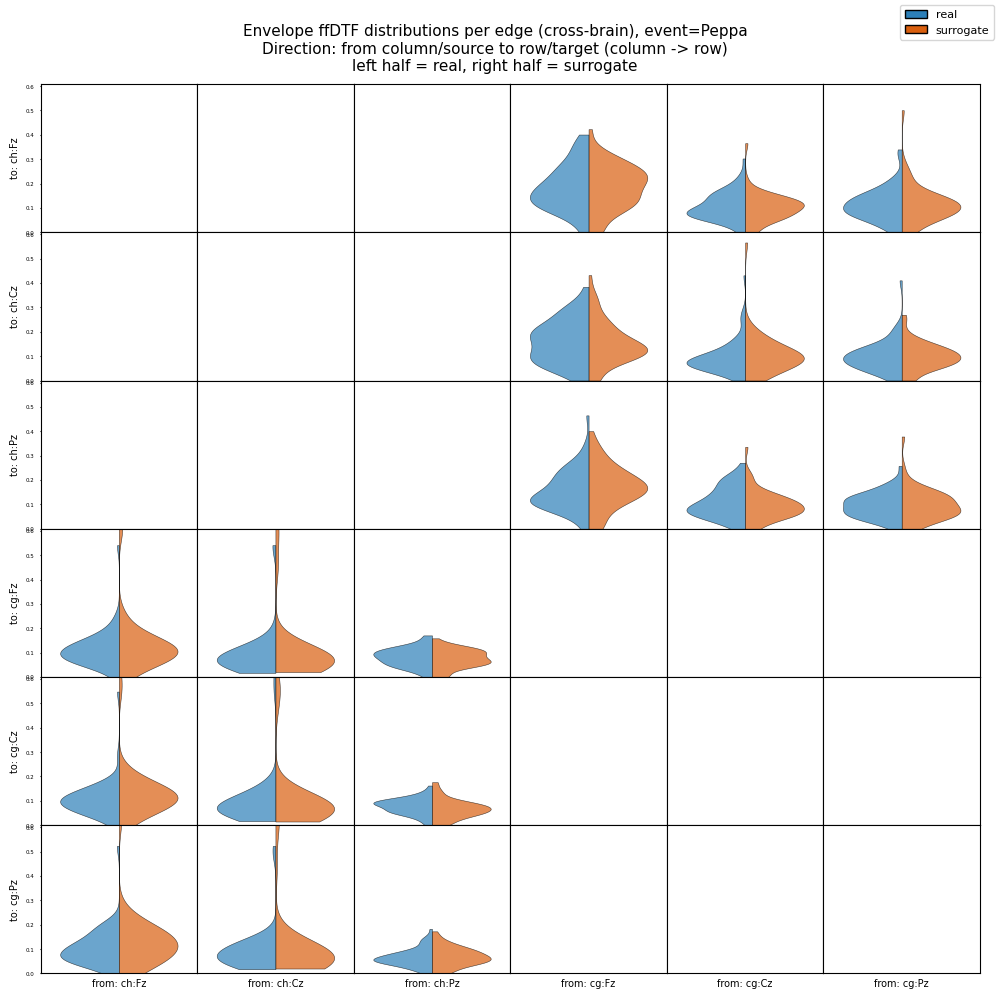

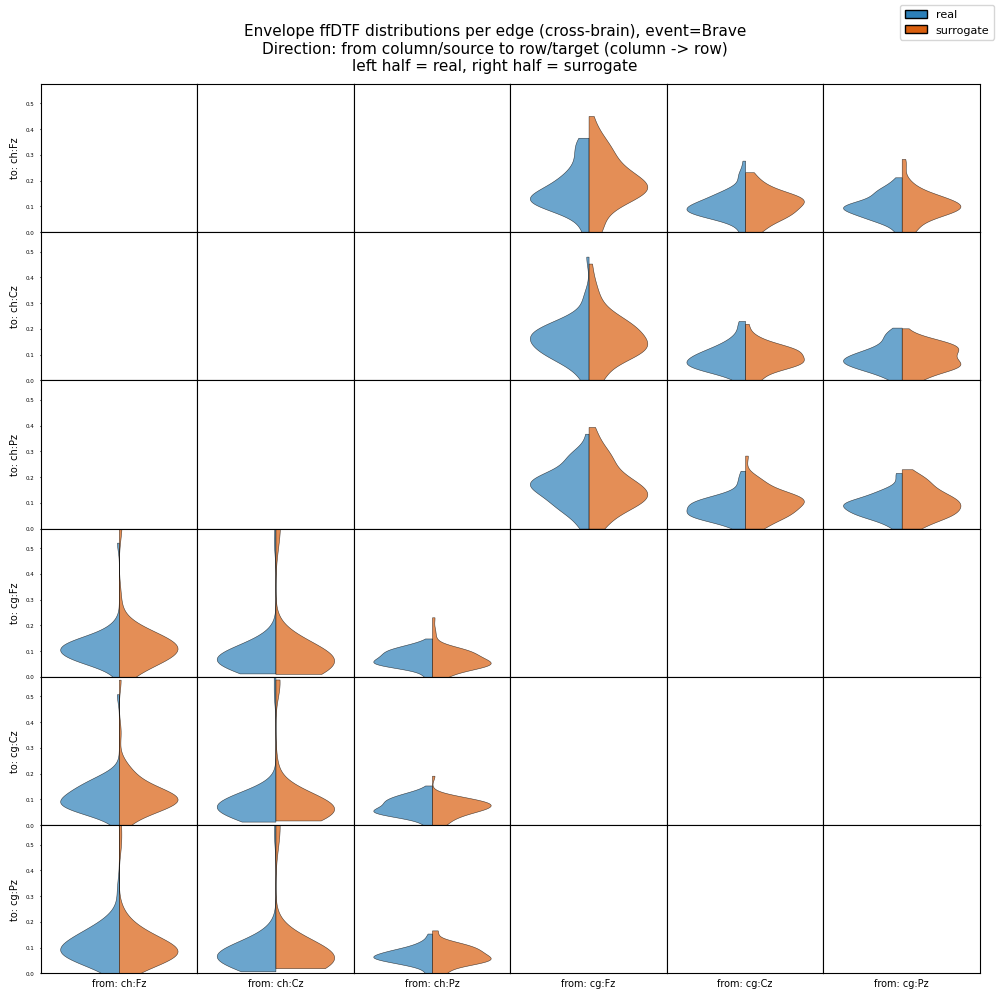

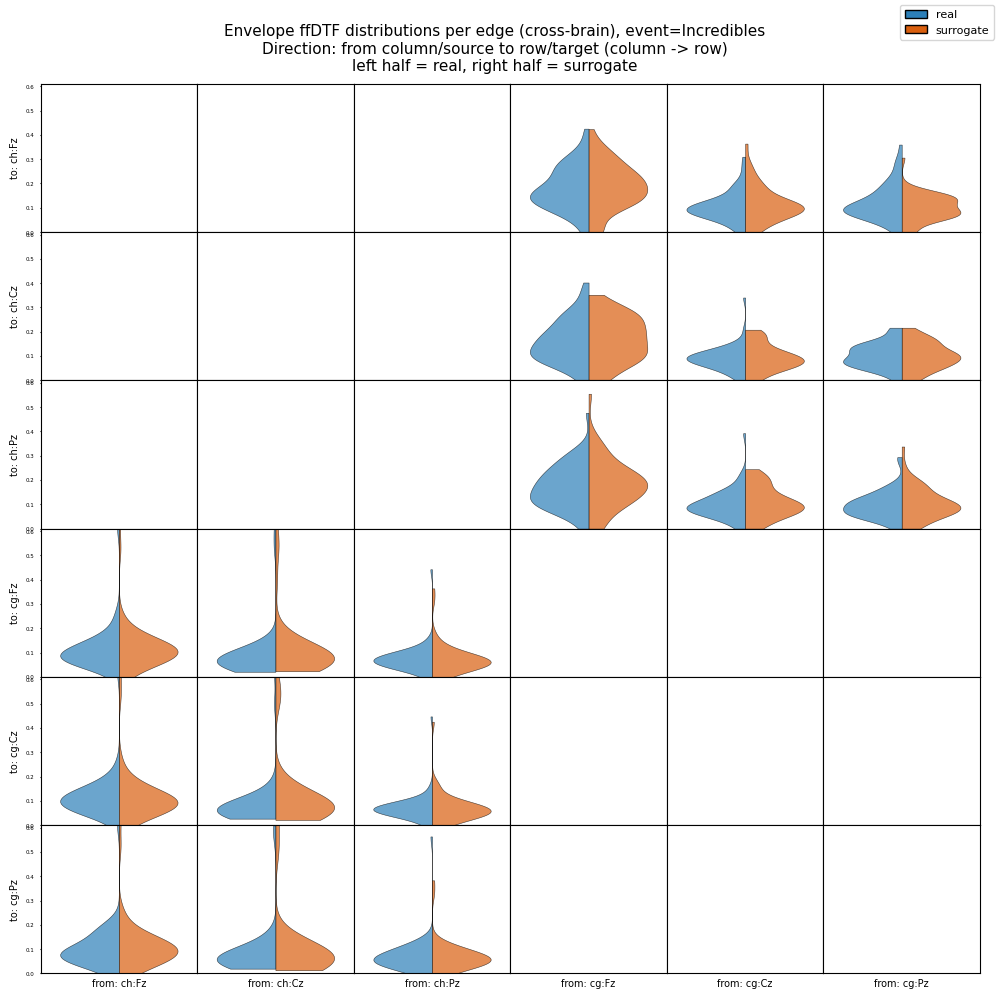

In [41]:
# Split-violin plots: cross-brain, real vs surrogate, per event
plot_split_violin_grid(
    ffdtf_env_df_pre,
    group_col='pair_type',
    groups=('real', 'surrogate'),
    target_events=TARGET_EVENTS,
    value_col='ff_dtf',
    channel_col='channel_pair',
    event_col='event',
    filter_cross_brain=True,
    left_color='#2C7FB8',
    right_color='#D95F0E',
    title_prefix='Envelope ffDTF distributions per edge (cross-brain)',
)

#### Test 1: Mean Difference (Permutation)

Run an edge-wise two-sided permutation test on mean ffDTF difference (real minus surrogate), with BH-FDR correction.

In [42]:
# Test 1: edge-wise mean-difference permutation (real vs surrogate)
edge_test_df, edge_test_summary = run_edgewise_permutation_test(
    ffdtf_env_df_pre,
    group_col='pair_type',
    groups=('real', 'surrogate'),
    pair_id_col='surrogate_pair_id',
    alpha=ALPHA,
    n_perm=N_PERM,
    min_pairs_per_group=MIN_PAIRS_PER_GROUP,
    random_seed=RANDOM_SEED_TEST,
    aggregate_over_events=True,
    filter_cross_brain=True,
    value_col='ff_dtf',
    channel_col='channel_pair',
)

print('\nTest 1 (mean-difference permutation): real vs surrogate')
print(f"  Tested edges: {edge_test_summary['tested_edges']}")
print(f"  Significant after BH-FDR (alpha={ALPHA}): {edge_test_summary['n_significant_fdr']}")
print(f"  Any significant edge?: {edge_test_summary['any_significant']}")
if edge_test_summary['message'] != 'OK':
    print(f"  Note: {edge_test_summary['message']}")
if not edge_test_df.empty:
    display(edge_test_df.head(30))
    if edge_test_summary['any_significant']:
        print('\nSignificant edges (FDR):')
        display(edge_test_df.loc[edge_test_df['significant_fdr']].sort_values('q_fdr_bh'))



Test 1 (mean-difference permutation): real vs surrogate
  Tested edges: 18
  Significant after BH-FDR (alpha=0.05): 0
  Any significant edge?: False


,channel_pair,n_real,n_surrogate,mean_real,mean_surrogate,diff_real_minus_surrogate,p_perm,q_fdr_bh,significant_fdr
0,ch:Fz->cg:Fz,53,50,0.114132,0.129716,-0.015584,0.387323,0.890004,False
1,cg:Fz->ch:Fz,53,50,0.177801,0.189776,-0.011975,0.412917,0.890004,False
2,ch:Pz->cg:Cz,53,50,0.075109,0.069824,0.005285,0.422316,0.890004,False
3,ch:Cz->cg:Fz,53,50,0.091551,0.110625,-0.019074,0.427315,0.890004,False
4,cg:Pz->ch:Pz,53,50,0.095955,0.102119,-0.006165,0.472705,0.890004,False
5,ch:Fz->cg:Cz,53,50,0.113921,0.125041,-0.011121,0.505699,0.890004,False
6,ch:Cz->cg:Cz,53,50,0.092092,0.107790,-0.015698,0.523495,0.890004,False
7,ch:Fz->cg:Pz,53,50,0.111422,0.123175,-0.011753,0.531294,0.890004,False
8,cg:Pz->ch:Fz,53,50,0.113252,0.107339,0.005914,0.537692,0.890004,False
9,ch:Pz->cg:Fz,53,50,0.077729,0.073553,0.004176,0.539492,0.890004,False


#### Test 2: Distribution Shape (KS + Permutation)

Run an edge-wise KS statistic with permutation p-values to compare full distribution shape between real and surrogate dyads, with BH-FDR correction.

In [43]:
# Test 2: edge-wise distribution-shape test (KS + permutation)
shape_test_df, shape_test_summary = run_edgewise_shape_test(
    ffdtf_env_df_pre,
    group_col='pair_type',
    groups=('real', 'surrogate'),
    pair_id_col='surrogate_pair_id',
    alpha=ALPHA_SHAPE,
    n_perm=N_PERM_SHAPE,
    min_pairs_per_group=MIN_PAIRS_PER_GROUP_SHAPE,
    random_seed=RANDOM_SEED_SHAPE,
    aggregate_over_events=True,
    filter_cross_brain=True,
    value_col='ff_dtf',
    channel_col='channel_pair',
)

print('\nTest 2 (distribution shape, KS + permutation): real vs surrogate')
print(f"  Tested edges: {shape_test_summary['tested_edges']}")
print(f"  Significant after BH-FDR (alpha={ALPHA_SHAPE}): {shape_test_summary['n_significant_fdr']}")
print(f"  Any significant edge?: {shape_test_summary['any_significant']}")
if shape_test_summary['message'] != 'OK':
    print(f"  Note: {shape_test_summary['message']}")
if not shape_test_df.empty:
    display(shape_test_df.head(30))
    if shape_test_summary['any_significant']:
        print('\nSignificant edges (FDR):')
        display(shape_test_df.loc[shape_test_df['significant_fdr']].sort_values('q_fdr_bh'))



Test 2 (distribution shape, KS + permutation): real vs surrogate
  Tested edges: 18
  Significant after BH-FDR (alpha=0.05): 0
  Any significant edge?: False


,channel_pair,n_real,n_surrogate,median_real,median_surrogate,ks_stat,p_perm,q_fdr_bh,significant_fdr
0,cg:Cz->ch:Cz,53,50,0.086360,0.105060,0.274717,0.033593,0.604679,False
1,ch:Pz->cg:Cz,53,50,0.073428,0.066864,0.198113,0.214957,0.796341,False
2,cg:Fz->ch:Fz,53,50,0.179022,0.187632,0.196226,0.229754,0.796341,False
3,ch:Cz->cg:Cz,53,50,0.073812,0.075303,0.176981,0.335733,0.796341,False
4,ch:Cz->cg:Pz,53,50,0.074228,0.068016,0.175094,0.362727,0.796341,False
5,cg:Fz->ch:Pz,53,50,0.172605,0.171332,0.174717,0.364327,0.796341,False
6,ch:Fz->cg:Pz,53,50,0.096653,0.107499,0.173962,0.367127,0.796341,False
7,cg:Fz->ch:Cz,53,50,0.156257,0.173740,0.159245,0.461708,0.796341,False
8,cg:Cz->ch:Fz,53,50,0.109884,0.111836,0.155849,0.491502,0.796341,False
9,cg:Pz->ch:Pz,53,50,0.097982,0.099881,0.156981,0.498700,0.796341,False


## Group differences TD vs ASD

### TD vs ASD: Split-Violin Distributions

Compare cross-brain envelope ffDTF distributions edge-wise between real TD and ASD dyads (left half = TD, right half = ASD).

### TD vs ASD: Split-Violin Distributions

#### Aggregated over events (mean per dyad-edge)

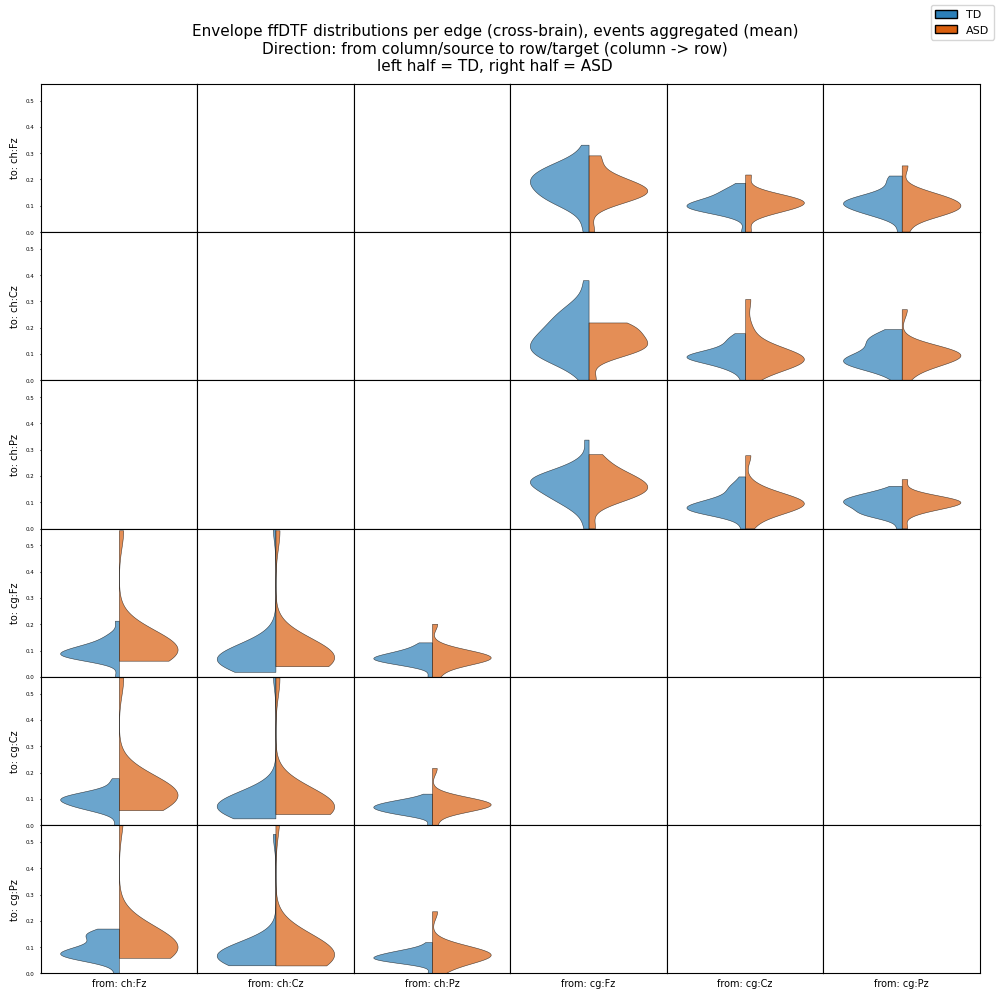

#### Separate events

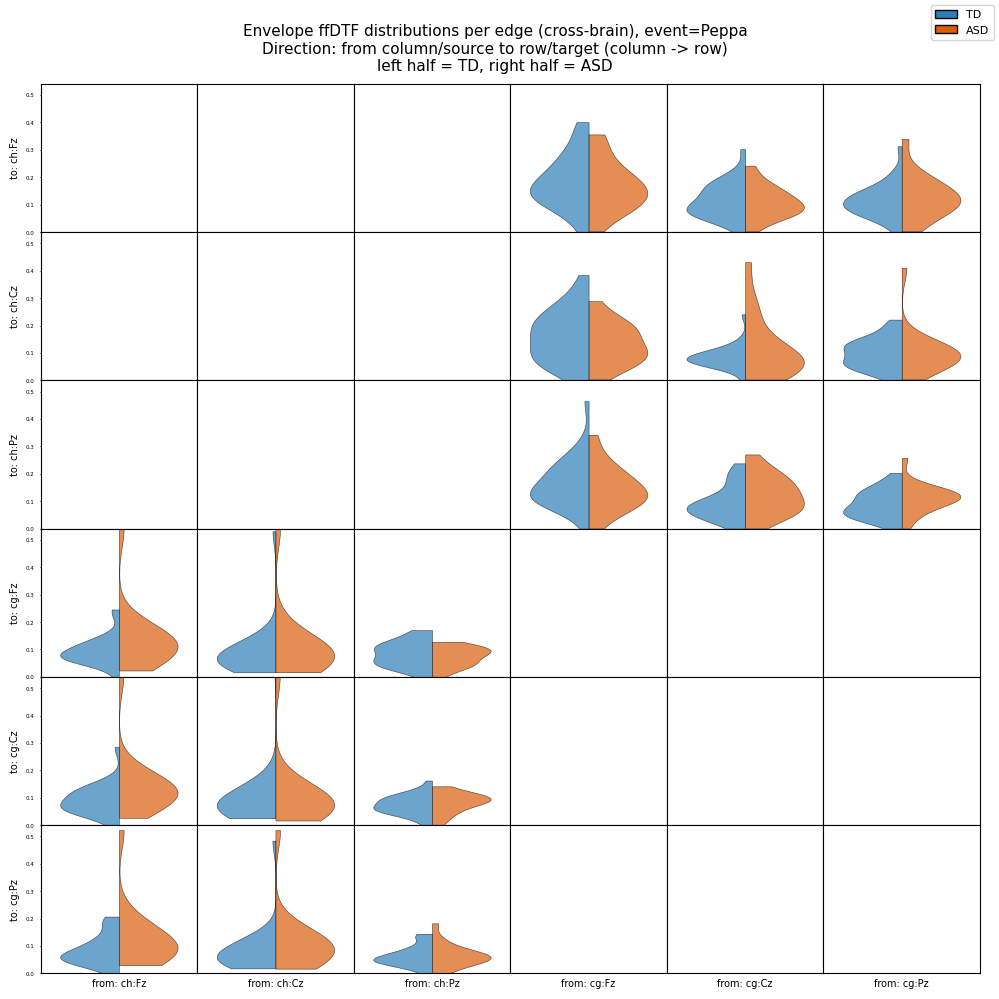

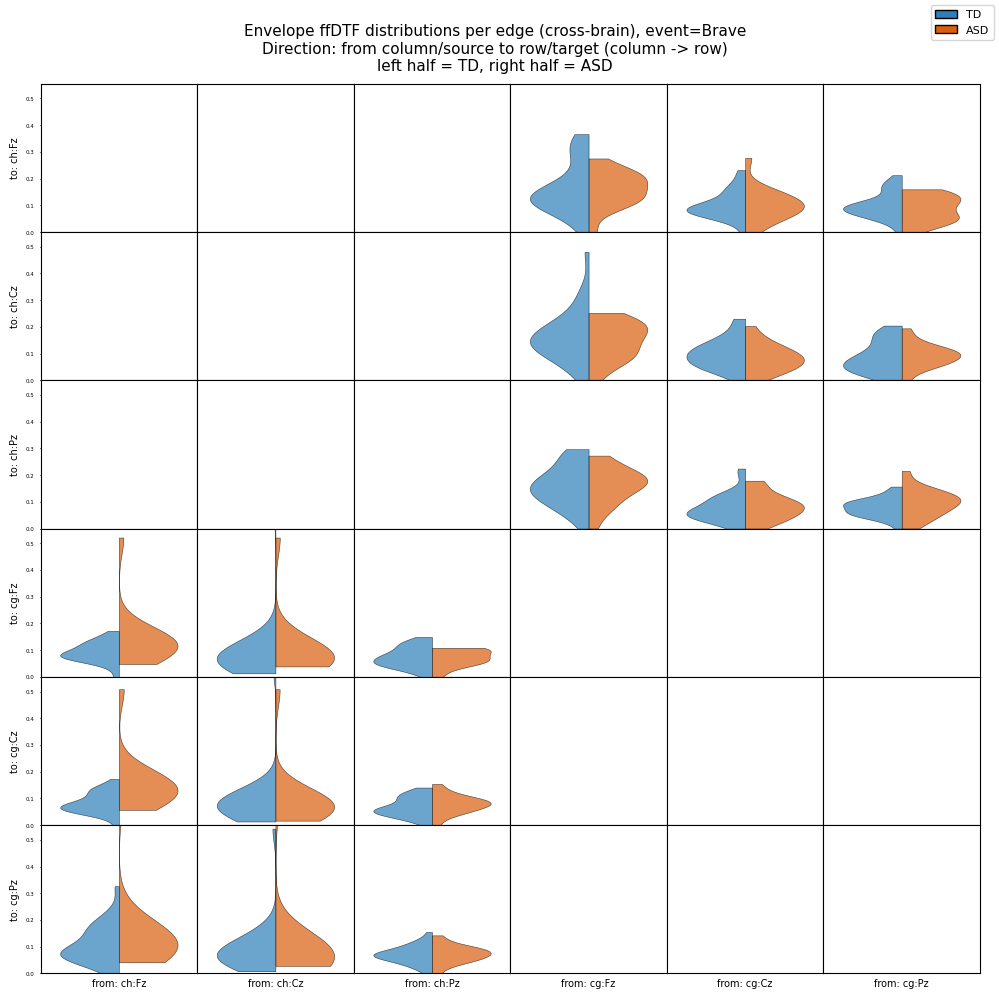

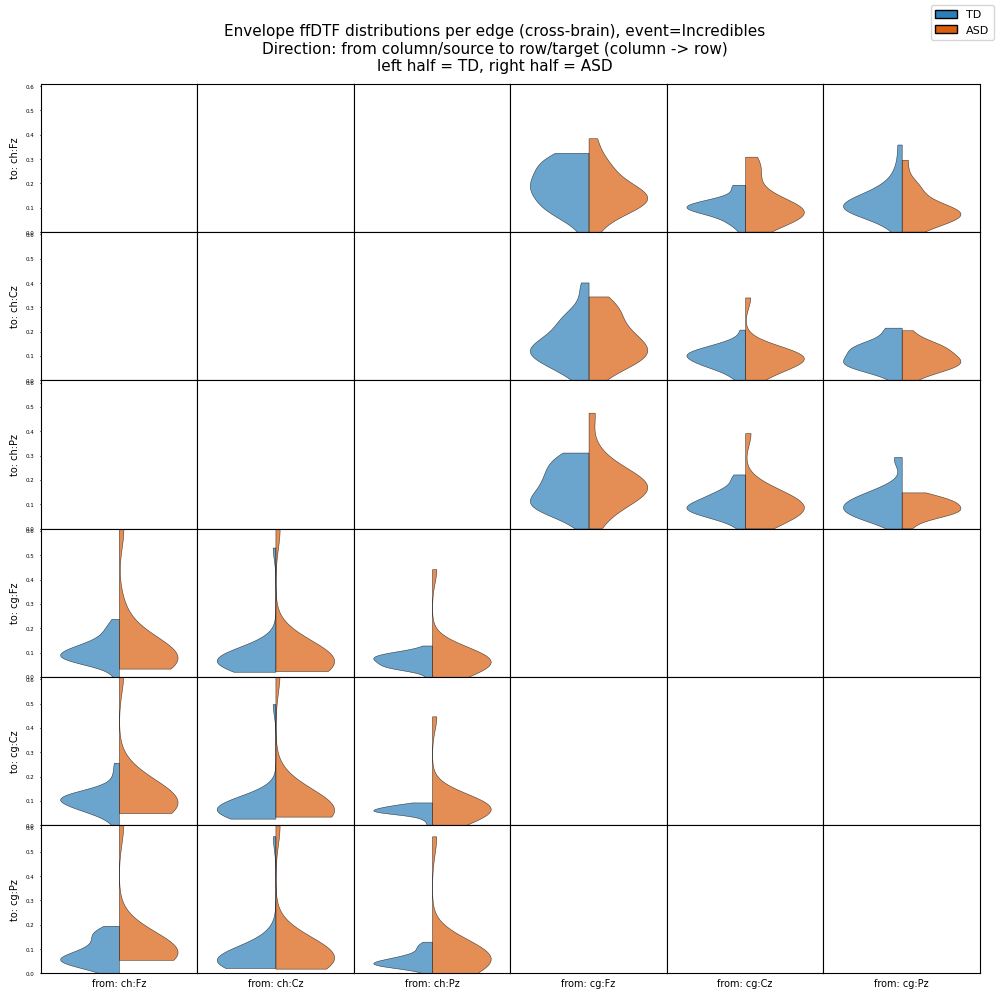

In [44]:
# TD_ASD_V2
from IPython.display import Markdown, display

display(Markdown('### TD vs ASD: Split-Violin Distributions'))

td_asd_df_pre = prepare_td_asd_df(ffdtf_env_df, filter_cross_brain=True)

if td_asd_df_pre.empty:
    print('No TD/ASD rows available after filtering.')
else:
    display(Markdown('#### Aggregated over events (mean per dyad-edge)'))
    plot_split_violin_grid(
        td_asd_df_pre,
        group_col='group_binary',
        groups=('TD', 'ASD'),
        target_events=TARGET_EVENTS,
        value_col='ff_dtf',
        channel_col='channel_pair',
        event_col='event',
        filter_cross_brain=False,
        left_color='#2C7FB8',
        right_color='#D95F0E',
        title_prefix='Envelope ffDTF distributions per edge (cross-brain)',
        aggregate_over_events=True,
        iterate_over_events=False,
        aggregate_id_col='dyadID',
        aggregate_func='mean',
    )

    display(Markdown('#### Separate events'))
    plot_split_violin_grid(
        td_asd_df_pre,
        group_col='group_binary',
        groups=('TD', 'ASD'),
        target_events=TARGET_EVENTS,
        value_col='ff_dtf',
        channel_col='channel_pair',
        event_col='event',
        filter_cross_brain=False,
        left_color='#2C7FB8',
        right_color='#D95F0E',
        title_prefix='Envelope ffDTF distributions per edge (cross-brain)',
        aggregate_over_events=False,
        iterate_over_events=True,
    )

### TD vs ASD: Mean Difference (Permutation Test)

In [45]:
# TD_ASD_V2
from IPython.display import Markdown, display

display(Markdown('### TD vs ASD: Mean Difference (Permutation Test)'))

td_asd_df_pre = prepare_td_asd_df(ffdtf_env_df, filter_cross_brain=True)

td_asd_perm_df, td_asd_perm_summary = run_edgewise_permutation_test(
    td_asd_df_pre,
    group_col='group_binary',
    groups=('TD', 'ASD'),
    pair_id_col='dyadID',
    alpha=ALPHA,
    n_perm=N_PERM,
    min_pairs_per_group=MIN_PAIRS_PER_GROUP,
    random_seed=RANDOM_SEED_TEST,
    aggregate_over_events=True,
    filter_cross_brain=False,
    value_col='ff_dtf',
    channel_col='channel_pair',
)

print('\nTD vs ASD permutation test')
print(f"  Tested edges: {td_asd_perm_summary['tested_edges']}")
print(f"  Significant after BH-FDR (alpha={ALPHA}): {td_asd_perm_summary['n_significant_fdr']}")
print(f"  Any significant edge?: {td_asd_perm_summary['any_significant']}")
if td_asd_perm_summary['message'] != 'OK':
    print(f"  Note: {td_asd_perm_summary['message']}")
if not td_asd_perm_df.empty:
    display(td_asd_perm_df.head(30))
    if td_asd_perm_summary['any_significant']:
        print('\nSignificant edges (FDR):')
        display(td_asd_perm_df.loc[td_asd_perm_df['significant_fdr']].sort_values('q_fdr_bh'))


### TD vs ASD: Mean Difference (Permutation Test)


TD vs ASD permutation test
  Tested edges: 18
  Significant after BH-FDR (alpha=0.05): 0
  Any significant edge?: False


,channel_pair,n_TD,n_ASD,mean_TD,mean_ASD,diff_TD_minus_ASD,p_perm,q_fdr_bh,significant_fdr
0,ch:Fz->cg:Cz,26,16,0.095227,0.143950,-0.048723,0.017996,0.323935,False
1,ch:Pz->cg:Cz,26,16,0.068265,0.083427,-0.015162,0.162168,0.801740,False
2,ch:Fz->cg:Fz,26,16,0.100044,0.134029,-0.033985,0.163567,0.801740,False
3,ch:Fz->cg:Pz,26,16,0.096452,0.133253,-0.036800,0.178164,0.801740,False
4,ch:Pz->cg:Pz,26,16,0.064713,0.076922,-0.012209,0.318136,0.994601,False
5,cg:Fz->ch:Fz,26,16,0.180811,0.166604,0.014207,0.512098,0.994601,False
6,cg:Cz->ch:Pz,26,16,0.094234,0.104529,-0.010294,0.514097,0.994601,False
7,cg:Fz->ch:Cz,26,16,0.163468,0.149600,0.013869,0.559288,0.994601,False
8,cg:Pz->ch:Fz,26,16,0.116018,0.106993,0.009025,0.576285,0.994601,False
9,ch:Cz->cg:Pz,26,16,0.085992,0.105882,-0.019889,0.582883,0.994601,False


### TD vs ASD: Distribution Shape (KS + Permutation)

In [46]:
# TD_ASD_V2
from IPython.display import Markdown, display

display(Markdown('### TD vs ASD: Distribution Shape (KS + Permutation)'))

td_asd_df_pre = prepare_td_asd_df(ffdtf_env_df, filter_cross_brain=True)

td_asd_shape_df, td_asd_shape_summary = run_edgewise_shape_test(
    td_asd_df_pre,
    group_col='group_binary',
    groups=('TD', 'ASD'),
    pair_id_col='dyadID',
    alpha=ALPHA_SHAPE,
    n_perm=N_PERM_SHAPE,
    min_pairs_per_group=MIN_PAIRS_PER_GROUP_SHAPE,
    random_seed=RANDOM_SEED_SHAPE,
    aggregate_over_events=True,
    filter_cross_brain=False,
    value_col='ff_dtf',
    channel_col='channel_pair',
)

print('\nTD vs ASD shape test (KS + permutation)')
print(f"  Tested edges: {td_asd_shape_summary['tested_edges']}")
print(f"  Significant after BH-FDR (alpha={ALPHA_SHAPE}): {td_asd_shape_summary['n_significant_fdr']}")
print(f"  Any significant edge?: {td_asd_shape_summary['any_significant']}")
if td_asd_shape_summary['message'] != 'OK':
    print(f"  Note: {td_asd_shape_summary['message']}")
if not td_asd_shape_df.empty:
    display(td_asd_shape_df.head(30))
    if td_asd_shape_summary['any_significant']:
        print('\nSignificant edges (FDR):')
        display(td_asd_shape_df.loc[td_asd_shape_df['significant_fdr']].sort_values('q_fdr_bh'))


### TD vs ASD: Distribution Shape (KS + Permutation)


TD vs ASD shape test (KS + permutation)
  Tested edges: 18
  Significant after BH-FDR (alpha=0.05): 0
  Any significant edge?: False


,channel_pair,n_TD,n_ASD,median_TD,median_ASD,ks_stat,p_perm,q_fdr_bh,significant_fdr
0,ch:Pz->cg:Cz,26,16,0.069435,0.078367,0.322115,0.188562,0.739292,False
1,ch:Fz->cg:Cz,26,16,0.098706,0.115621,0.322115,0.198160,0.739292,False
2,cg:Cz->ch:Pz,26,16,0.085115,0.098464,0.302885,0.257349,0.739292,False
3,cg:Pz->ch:Cz,26,16,0.089781,0.093479,0.283654,0.327534,0.739292,False
4,ch:Cz->cg:Cz,26,16,0.076978,0.068308,0.278846,0.346931,0.739292,False
5,cg:Fz->ch:Fz,26,16,0.180642,0.150563,0.274038,0.368726,0.739292,False
6,cg:Fz->ch:Cz,26,16,0.145674,0.147155,0.269231,0.386923,0.739292,False
7,cg:Cz->ch:Cz,26,16,0.090024,0.082816,0.269231,0.388322,0.739292,False
8,ch:Cz->cg:Pz,26,16,0.069743,0.075438,0.259615,0.408318,0.739292,False
9,ch:Fz->cg:Fz,26,16,0.093426,0.110838,0.264423,0.410718,0.739292,False


### TD vs ASD: Repeated-Measures Edgewise Test (Group, Movie, Group×Movie)

This analysis tests, for each edge, three effects while accounting for repeated measurements across movies within the same dyad:

1. **Group main effect (TD vs ASD)**: overall group difference across movies.
2. **Movie main effect**: overall difference across the three movies.
3. **Group × Movie interaction**: whether TD-ASD differences depend on movie.

#### RM-aware test statistics

To better separate between-dyad and within-dyad variance:

- **Group effect** is tested on **dyad means** (between-dyad test).
- **Movie** and **Group × Movie** are tested using **within-dyad demeaned** data.

For each edge, we compute partial F-statistics from nested linear models in the corresponding space.

#### Permutation strategy (repeated-measures aware)

Permutation is restricted to preserve the dyad-level dependence structure:

- **Group test**: Freedman-Lane style at dyad level, with residual permutation across dyads.
- **Movie test**: Freedman-Lane style on within-dyad demeaned data, with within-dyad residual permutation across movies.
- **Interaction test**: Freedman-Lane style from the within-dyad movie-only model, with within-dyad residual permutation.

This yields robust p-values without relying on normality of edge distributions.

#### Reproducibility and safeguards

- Permutations use a **deterministic per-edge seed** derived from edge name and base seed, so results do not depend on edge iteration order.
- Group labels are explicitly validated to be exactly `TD` and `ASD` for each tested edge.

#### Multiple testing

Because this is done edgewise, p-values are BH-FDR corrected separately for each effect family (`group`, `movie`, `interaction`) across edges.

#### Implemenatation of tests

In [26]:
# TD vs ASD repeated-measures edgewise permutation tests: group, movie, interaction
import hashlib
import numpy as np
import pandas as pd

# Configuration for repeated-measures permutation tests
N_PERM_RM = 5000
MIN_DYADS_PER_GROUP_RM = 5
RANDOM_SEED_RM = 777

def _ols_fit(y, X):
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    resid = y - y_hat
    rss = float(np.dot(resid, resid))
    return beta, y_hat, resid, rss

def _partial_f_from_rss(rss_reduced, rss_full, df1, df2):
    num = (rss_reduced - rss_full) / max(df1, 1)
    den = rss_full / max(df2, 1)
    if den <= 0:
        return np.nan
    return float(num / den)

def _partial_f(y, X_full, X_reduced):
    _, _, _, rss_full = _ols_fit(y, X_full)
    _, _, _, rss_reduced = _ols_fit(y, X_reduced)
    df1 = X_full.shape[1] - X_reduced.shape[1]
    df2 = len(y) - X_full.shape[1]
    if df1 <= 0 or df2 <= 0:
        return np.nan
    return _partial_f_from_rss(rss_reduced, rss_full, df1, df2)

def _demean_within_blocks(vec, block_ids):
    out = np.asarray(vec, dtype=float).copy()
    for b in np.unique(block_ids):
        idx = np.where(block_ids == b)[0]
        out[idx] = out[idx] - np.mean(out[idx])
    return out

def _permute_within_blocks(vec, block_ids, rng):
    out = np.array(vec, copy=True)
    for b in np.unique(block_ids):
        idx = np.where(block_ids == b)[0]
        out[idx] = out[idx[rng.permutation(len(idx))]]
    return out

def _permute_across_units(vec, rng):
    idx = rng.permutation(len(vec))
    return np.asarray(vec)[idx]

def _edge_seed(edge_name, base_seed):
    key = f'{int(base_seed)}|{str(edge_name)}'.encode('utf-8')
    digest = hashlib.blake2b(key, digest_size=8).digest()
    return int.from_bytes(digest, byteorder='little', signed=False) % (2**32 - 1)

def _build_edge_long_complete(edge_df, target_events):
    # Aggregate in case multiple rows exist for same dyad-event-edge
    agg = (
        edge_df.groupby(['dyadID', 'group_binary', 'event'], as_index=False)['ff_dtf']
        .mean()
    )

    target_events = [str(e) for e in target_events]
    agg = agg.loc[agg['event'].isin(target_events)].copy()

    # Keep only dyads with complete movie set
    event_set = set(target_events)
    ev_by_dyad = agg.groupby('dyadID')['event'].apply(lambda s: set(map(str, s))).to_dict()
    keep_dyads = sorted([d for d, evs in ev_by_dyad.items() if evs == event_set])
    agg = agg.loc[agg['dyadID'].isin(keep_dyads)].copy()
    if agg.empty:
        return None

    # Ensure each dyad has a single stable group label
    g_per_dyad = agg.groupby('dyadID')['group_binary'].nunique()
    good_dyads = g_per_dyad[g_per_dyad == 1].index.tolist()
    agg = agg.loc[agg['dyadID'].isin(good_dyads)].copy()
    if agg.empty:
        return None

    # Build complete long table with deterministic order dyad x movie
    group_map = agg.groupby('dyadID')['group_binary'].first().to_dict()
    rows = []
    for dyad in sorted(group_map.keys()):
        for ev in target_events:
            tmp = agg.loc[(agg['dyadID'] == dyad) & (agg['event'] == ev), 'ff_dtf']
            if len(tmp) != 1:
                return None
            rows.append({
                'dyadID': dyad,
                'group_binary': group_map[dyad],
                'event': ev,
                'ff_dtf': float(tmp.iloc[0]),
            })

    out = pd.DataFrame(rows)
    return out

def _run_edge_rm_tests(edge_df, target_events, n_perm=5000, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)

    long_df = _build_edge_long_complete(edge_df, target_events)
    if long_df is None or long_df.empty:
        return None

    labels = set(long_df['group_binary'].astype(str).unique())
    if labels != {'TD', 'ASD'}:
        return {
            'ok': False,
            'reason': f'Unexpected group labels for edge: {sorted(labels)}',
            'n_td': int((long_df['group_binary'] == 'TD').sum() > 0),
            'n_asd': int((long_df['group_binary'] == 'ASD').sum() > 0),
            'n_dyads_total': int(long_df['dyadID'].nunique()),
        }

    # Build repeated-measures arrays
    y = long_df['ff_dtf'].to_numpy(dtype=float)
    g = (long_df['group_binary'].to_numpy() == 'ASD').astype(float)
    events = [str(e) for e in target_events]
    m1 = (long_df['event'].to_numpy() == events[1]).astype(float)
    m2 = (long_df['event'].to_numpy() == events[2]).astype(float)
    block_ids = long_df['dyadID'].to_numpy()

    # Dyad-level counts
    n_by_group = long_df.groupby('group_binary')['dyadID'].nunique().to_dict()
    n_td = int(n_by_group.get('TD', 0))
    n_asd = int(n_by_group.get('ASD', 0))
    if min(n_td, n_asd) < MIN_DYADS_PER_GROUP_RM:
        return {
            'ok': False,
            'reason': f'Insufficient dyads per group after complete-case filtering (TD={n_td}, ASD={n_asd}).',
            'n_td': n_td,
            'n_asd': n_asd,
            'n_dyads_total': int(n_td + n_asd),
        }

    # -----------------------------
    # Group effect (between-dyad): test on dyad means
    # -----------------------------
    dyad_summary = (
        long_df.groupby('dyadID', as_index=False)
        .agg(group_binary=('group_binary', 'first'), ff_dtf_mean=('ff_dtf', 'mean'))
        .sort_values('dyadID')
        .reset_index(drop=True)
    )
    y_d = dyad_summary['ff_dtf_mean'].to_numpy(dtype=float)
    g_d = (dyad_summary['group_binary'].to_numpy() == 'ASD').astype(float)

    Xg0 = np.ones((len(y_d), 1), dtype=float)
    Xg1 = np.column_stack([np.ones(len(y_d), dtype=float), g_d])
    F_group_obs = _partial_f(y_d, Xg1, Xg0)

    _, yhat_g0, resid_g0, _ = _ols_fit(y_d, Xg0)
    perm_group = []
    for _ in range(n_perm):
        y_perm = yhat_g0 + _permute_across_units(resid_g0, rng)
        perm_group.append(_partial_f(y_perm, Xg1, Xg0))

    # -----------------------------
    # Within-dyad effects: movie and interaction on demeaned data
    # -----------------------------
    y_w = _demean_within_blocks(y, block_ids)
    m1_w = _demean_within_blocks(m1, block_ids)
    m2_w = _demean_within_blocks(m2, block_ids)
    gm1_w = _demean_within_blocks(g * m1, block_ids)
    gm2_w = _demean_within_blocks(g * m2, block_ids)

    Xm0 = np.zeros((len(y_w), 0), dtype=float)
    Xm = np.column_stack([m1_w, m2_w])
    Xmi = np.column_stack([m1_w, m2_w, gm1_w, gm2_w])

    F_movie_obs = _partial_f(y_w, Xm, Xm0)
    F_inter_obs = _partial_f(y_w, Xmi, Xm)

    # Movie test: Freedman-Lane from within-dyad null (no movie effect)
    _, yhat_m0, resid_m0, _ = _ols_fit(y_w, Xm0)
    perm_movie = []
    for _ in range(n_perm):
        y_perm = yhat_m0 + _permute_within_blocks(resid_m0, block_ids, rng)
        perm_movie.append(_partial_f(y_perm, Xm, Xm0))

    # Interaction test: Freedman-Lane from within-dyad movie-only model
    _, yhat_i0, resid_i0, _ = _ols_fit(y_w, Xm)
    perm_inter = []
    for _ in range(n_perm):
        y_perm = yhat_i0 + _permute_within_blocks(resid_i0, block_ids, rng)
        perm_inter.append(_partial_f(y_perm, Xmi, Xm))

    def _perm_pvalue(observed, perm_stats):
        perm_stats = np.asarray(perm_stats, dtype=float)
        perm_stats = perm_stats[np.isfinite(perm_stats)]
        if not np.isfinite(observed) or perm_stats.size == 0:
            return np.nan
        return float((1 + np.sum(perm_stats >= observed)) / (perm_stats.size + 1))

    p_group = _perm_pvalue(F_group_obs, perm_group)
    p_movie = _perm_pvalue(F_movie_obs, perm_movie)
    p_inter = _perm_pvalue(F_inter_obs, perm_inter)

    return {
        'ok': True,
        'n_td': n_td,
        'n_asd': n_asd,
        'n_dyads_total': int(n_td + n_asd),
        'F_group': float(F_group_obs),
        'F_movie': float(F_movie_obs),
        'F_interaction': float(F_inter_obs),
        'p_group_perm': p_group,
        'p_movie_perm': p_movie,
        'p_interaction_perm': p_inter,
    }

# Ensure TD/ASD dataframe is available
td_asd_df_pre = prepare_td_asd_df(ffdtf_env_df, filter_cross_brain=True)
if td_asd_df_pre.empty:
    raise RuntimeError('No TD/ASD rows available after filtering.')

edge_results = []
edge_skipped = []
edge_order = []

for edge, edge_df in td_asd_df_pre.groupby('channel_pair'):
    edge_order.append(edge)
    seed_edge = _edge_seed(edge, RANDOM_SEED_RM)
    rng_edge = np.random.default_rng(seed_edge)

    out = _run_edge_rm_tests(
        edge_df=edge_df,
        target_events=TARGET_EVENTS,
        n_perm=N_PERM_RM,
        rng=rng_edge,
    )
    if out is None or not out.get('ok', False):
        edge_skipped.append({
            'channel_pair': edge,
            'reason': 'No valid complete-case dyads.' if out is None else out.get('reason', 'Unknown'),
            'n_td': np.nan if out is None else out.get('n_td', np.nan),
            'n_asd': np.nan if out is None else out.get('n_asd', np.nan),
            'perm_seed': seed_edge,
        })
        continue

    edge_results.append({
        'channel_pair': edge,
        'perm_seed': seed_edge,
        **out,
    })

td_asd_rm_df = pd.DataFrame(edge_results)
td_asd_rm_skipped_df = pd.DataFrame(edge_skipped)

if td_asd_rm_df.empty:
    print('No edges could be tested with repeated-measures complete-case criteria.')
else:
    # BH-FDR separately per effect family across edges
    bh = globals().get('_bh_fdr', None)
    if bh is None:
        def bh(p_values):
            p = np.asarray(p_values, dtype=float)
            n = p.size
            order = np.argsort(p)
            p_sorted = p[order]
            q_sorted = np.empty(n, dtype=float)
            for i, pv in enumerate(p_sorted, start=1):
                q_sorted[i - 1] = pv * n / i
            q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
            q_sorted = np.clip(q_sorted, 0.0, 1.0)
            q = np.empty(n, dtype=float)
            q[order] = q_sorted
            return q

    td_asd_rm_df = td_asd_rm_df.sort_values('channel_pair').reset_index(drop=True)
    td_asd_rm_df['q_group_fdr'] = bh(td_asd_rm_df['p_group_perm'].to_numpy())
    td_asd_rm_df['q_movie_fdr'] = bh(td_asd_rm_df['p_movie_perm'].to_numpy())
    td_asd_rm_df['q_interaction_fdr'] = bh(td_asd_rm_df['p_interaction_perm'].to_numpy())

    td_asd_rm_df['sig_group_fdr_0p05'] = td_asd_rm_df['q_group_fdr'] < 0.05
    td_asd_rm_df['sig_movie_fdr_0p05'] = td_asd_rm_df['q_movie_fdr'] < 0.05
    td_asd_rm_df['sig_interaction_fdr_0p05'] = td_asd_rm_df['q_interaction_fdr'] < 0.05

    print('TD vs ASD repeated-measures edgewise permutation tests (RM-aware)')
    print(f'  Tested edges: {len(td_asd_rm_df)}')
    print(f'  Edge order logged for traceability: {len(edge_order)} edges')
    print(f"  Significant Group effects (FDR<0.05): {int(td_asd_rm_df['sig_group_fdr_0p05'].sum())}")
    print(f"  Significant Movie effects (FDR<0.05): {int(td_asd_rm_df['sig_movie_fdr_0p05'].sum())}")
    print(f"  Significant Group×Movie effects (FDR<0.05): {int(td_asd_rm_df['sig_interaction_fdr_0p05'].sum())}")

    display(
        td_asd_rm_df[[
            'channel_pair',
            'n_td', 'n_asd',
            'F_group', 'p_group_perm', 'q_group_fdr',
            'F_movie', 'p_movie_perm', 'q_movie_fdr',
            'F_interaction', 'p_interaction_perm', 'q_interaction_fdr',
            'sig_group_fdr_0p05', 'sig_movie_fdr_0p05', 'sig_interaction_fdr_0p05',
            'perm_seed',
        ]].sort_values('q_interaction_fdr').head(72)
    )

if not td_asd_rm_skipped_df.empty:
    print(f'Skipped edges: {len(td_asd_rm_skipped_df)}')
    display(td_asd_rm_skipped_df.head(20))

TD vs ASD repeated-measures edgewise permutation tests (RM-aware)
  Tested edges: 18
  Edge order logged for traceability: 18 edges
  Significant Group effects (FDR<0.05): 0
  Significant Movie effects (FDR<0.05): 0
  Significant Group×Movie effects (FDR<0.05): 0


,channel_pair,n_td,n_asd,F_group,p_group_perm,q_group_fdr,F_movie,p_movie_perm,q_movie_fdr,F_interaction,p_interaction_perm,q_interaction_fdr,sig_group_fdr_0p05,sig_movie_fdr_0p05,sig_interaction_fdr_0p05,perm_seed
0,cg:Cz->ch:Cz,26,16,0.119109,0.747051,0.995401,0.027889,0.980604,0.980604,4.859301,0.076185,0.457109,False,False,False,3962380028
8,cg:Pz->ch:Pz,26,16,0.236014,0.632673,0.995401,1.771780,0.315937,0.947810,4.022117,0.058188,0.457109,False,False,False,1771733792
12,ch:Fz->cg:Cz,26,16,3.990678,0.016397,0.295141,0.315910,0.813837,0.976605,4.280860,0.059188,0.457109,False,False,False,1746707855
2,cg:Cz->ch:Pz,26,16,0.436839,0.517097,0.995401,5.246262,0.036793,0.400720,1.212596,0.475505,0.807069,False,False,False,496579905
7,cg:Pz->ch:Fz,26,16,0.323588,0.579484,0.995401,4.167726,0.066787,0.400720,2.285017,0.252350,0.807069,False,False,False,3013841829
6,cg:Pz->ch:Cz,26,16,0.000693,0.977405,0.995401,2.127261,0.253549,0.912777,0.947909,0.582883,0.807069,False,False,False,1287026902
3,cg:Fz->ch:Cz,26,16,0.337132,0.567886,0.995401,0.485466,0.716657,0.976605,1.295322,0.453909,0.807069,False,False,False,2219934737
5,cg:Fz->ch:Pz,26,16,0.000038,0.995401,0.995401,0.674639,0.633273,0.976605,1.271803,0.453109,0.807069,False,False,False,1892538714
13,ch:Fz->cg:Fz,26,16,1.870795,0.177764,0.799940,0.165002,0.896821,0.980604,2.390778,0.259548,0.807069,False,False,False,1095100789
9,ch:Cz->cg:Cz,26,16,0.074924,0.828034,0.995401,2.257028,0.222755,0.912777,1.033061,0.537293,0.807069,False,False,False,3618508545


In [27]:
p_cols = [c for c in td_asd_rm_df.columns if str(c).startswith('p_')]
if len(p_cols) == 0:
    print("No columns starting with 'p_' were found in td_asd_rm_df.")
else:
    mask_sig = (td_asd_rm_df[p_cols] < 0.05).any(axis=1)
    display(
        td_asd_rm_df.loc[mask_sig, [
            'channel_pair',
            'n_td', 'n_asd',
            'F_group', 'p_group_perm', 'q_group_fdr',
            'F_movie', 'p_movie_perm', 'q_movie_fdr',
            'F_interaction', 'p_interaction_perm', 'q_interaction_fdr',
            'sig_group_fdr_0p05', 'sig_movie_fdr_0p05', 'sig_interaction_fdr_0p05',
            'perm_seed',
        ]].sort_values('q_interaction_fdr')
    )

,channel_pair,n_td,n_asd,F_group,p_group_perm,q_group_fdr,F_movie,p_movie_perm,q_movie_fdr,F_interaction,p_interaction_perm,q_interaction_fdr,sig_group_fdr_0p05,sig_movie_fdr_0p05,sig_interaction_fdr_0p05,perm_seed
12,ch:Fz->cg:Cz,26,16,3.990678,0.016397,0.295141,0.315910,0.813837,0.976605,4.280860,0.059188,0.457109,False,False,False,1746707855
2,cg:Cz->ch:Pz,26,16,0.436839,0.517097,0.995401,5.246262,0.036793,0.400720,1.212596,0.475505,0.807069,False,False,False,496579905
14,ch:Fz->cg:Pz,26,16,1.837179,0.171366,0.799940,4.567149,0.048790,0.400720,0.098726,0.928614,0.928614,False,False,False,2089519710


### Aggregated TD vs ASD RM Tests: Four Variants

This section adds four repeated-measures permutation analyses on **aggregated** connectivity statistics.

All variants reuse the same RM-aware testing framework used above (Group, Movie, Group×Movie), but differ in how edge-level values are aggregated before testing.

1. **Directional family only**: test only one direction family at a time (`ch->cg` or `cg->ch`).
2. **ROI-edge summaries**: collapse channel-level edges into ROI-to-ROI edges (e.g., frontal->parietal).
3. **Node outgoing strength**: per dyad/movie, aggregate all edges from a focal source node to all opposite-brain targets.
4. **Node incoming strength**: per dyad/movie, aggregate all edges arriving at a focal target node from all opposite-brain sources.

Each variant outputs a results table with permutation p-values and BH-FDR correction.

In [28]:
import re
import numpy as np
import pandas as pd

# ------------------------------
# Configuration for aggregated RM variants
# ------------------------------
AGG_DIRECTION_FAMILY = 'cg_to_ch'  # options: 'ch_to_cg', 'cg_to_ch'
AGG_METHOD = 'mean'                # options: 'mean', 'sum'
AGG_N_PERM = N_PERM_RM if 'N_PERM_RM' in globals() else 5000
AGG_MIN_DYADS_PER_GROUP = MIN_DYADS_PER_GROUP_RM if 'MIN_DYADS_PER_GROUP_RM' in globals() else 5
AGG_SEED_BASE = 1701

# ROI mapping can be adjusted to match your montage definitions.
ROI_PREFIX_MAP = {
    'F': 'frontal',
    'C': 'central',
    'P': 'parietal',
}
ROI_KEEP = {'frontal', 'central', 'parietal'}

# Node-level examples (edit as needed)
NODE_OUT_ROLE = 'cg'    # focal source role for outgoing statistic
NODE_OUT_NAME = 'Pz'    # focal source node
NODE_IN_ROLE = 'ch'     # focal target role for incoming statistic
NODE_IN_NAME = 'Fz'     # focal target node


def _agg_op(series, method='mean'):
    if method == 'sum':
        return float(series.sum())
    return float(series.mean())


def _parse_channel_pair(cp):
    text = str(cp).strip()
    m = re.match(r'^(ch|cg):([^\-\s>]+)\s*->\s*(ch|cg):([^\s]+)$', text)
    if m is None:
        return None
    return {
        'src_role': m.group(1),
        'src_node': m.group(2),
        'dst_role': m.group(3),
        'dst_node': m.group(4),
    }


def _node_to_roi(node_name):
    node = str(node_name).strip()
    if len(node) == 0:
        return 'other'
    prefix = node[0].upper()
    return ROI_PREFIX_MAP.get(prefix, 'other')


def _add_edge_parts(df):
    tmp = df.copy()
    parsed = tmp['channel_pair'].apply(_parse_channel_pair)
    tmp['src_role'] = parsed.apply(lambda x: np.nan if x is None else x['src_role'])
    tmp['src_node'] = parsed.apply(lambda x: np.nan if x is None else x['src_node'])
    tmp['dst_role'] = parsed.apply(lambda x: np.nan if x is None else x['dst_role'])
    tmp['dst_node'] = parsed.apply(lambda x: np.nan if x is None else x['dst_node'])
    tmp = tmp.dropna(subset=['src_role', 'src_node', 'dst_role', 'dst_node']).copy()
    return tmp


def _filter_direction_family(df, family='ch_to_cg'):
    if family == 'ch_to_cg':
        return df.loc[(df['src_role'] == 'ch') & (df['dst_role'] == 'cg')].copy()
    if family == 'cg_to_ch':
        return df.loc[(df['src_role'] == 'cg') & (df['dst_role'] == 'ch')].copy()
    raise ValueError(f'Unknown family: {family}')


def _bh_fdr_local(p_values):
    p = np.asarray(p_values, dtype=float)
    n = p.size
    if n == 0:
        return p
    order = np.argsort(p)
    p_sorted = p[order]
    q_sorted = np.empty(n, dtype=float)
    for i, pv in enumerate(p_sorted, start=1):
        q_sorted[i - 1] = pv * n / i
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0.0, 1.0)
    q = np.empty(n, dtype=float)
    q[order] = q_sorted
    return q


def _run_rm_on_aggregated_keys(df, key_col, n_perm=5000, seed_base=1701):
    out_rows = []
    skipped_rows = []

    for stat_key, part in df.groupby(key_col):
        seed = _edge_seed(str(stat_key), seed_base)
        rng = np.random.default_rng(seed)

        test_out = _run_edge_rm_tests(
            edge_df=part[['dyadID', 'group_binary', 'event', 'ff_dtf']].copy(),
            target_events=TARGET_EVENTS,
            n_perm=n_perm,
            rng=rng,
        )

        if test_out is None or not test_out.get('ok', False):
            skipped_rows.append({
                key_col: stat_key,
                'reason': 'No valid complete-case dyads.' if test_out is None else test_out.get('reason', 'Unknown'),
                'n_td': np.nan if test_out is None else test_out.get('n_td', np.nan),
                'n_asd': np.nan if test_out is None else test_out.get('n_asd', np.nan),
                'perm_seed': seed,
            })
            continue

        out_rows.append({
            key_col: stat_key,
            'perm_seed': seed,
            **test_out,
        })

    res = pd.DataFrame(out_rows)
    skipped = pd.DataFrame(skipped_rows)

    if not res.empty:
        bh = globals().get('_bh_fdr', _bh_fdr_local)
        res = res.sort_values(key_col).reset_index(drop=True)
        res['q_group_fdr'] = bh(res['p_group_perm'].to_numpy())
        res['q_movie_fdr'] = bh(res['p_movie_perm'].to_numpy())
        res['q_interaction_fdr'] = bh(res['p_interaction_perm'].to_numpy())

        res['sig_group_fdr_0p05'] = res['q_group_fdr'] < 0.05
        res['sig_movie_fdr_0p05'] = res['q_movie_fdr'] < 0.05
        res['sig_interaction_fdr_0p05'] = res['q_interaction_fdr'] < 0.05

    return res, skipped


# Base TD/ASD table reused by all variants
if 'td_asd_df_pre' in globals() and isinstance(td_asd_df_pre, pd.DataFrame) and not td_asd_df_pre.empty:
    td_asd_base = td_asd_df_pre.copy()
else:
    td_asd_base = prepare_td_asd_df(ffdtf_env_df, filter_cross_brain=True)

if td_asd_base.empty:
    raise RuntimeError('No TD/ASD rows available after filtering.')

if AGG_MIN_DYADS_PER_GROUP != MIN_DYADS_PER_GROUP_RM:
    MIN_DYADS_PER_GROUP_RM = AGG_MIN_DYADS_PER_GROUP


#### Version 1: Directionality-Specific Family (No Cross-Family Mixing)

This variant tests only one directional hypothesis family at a time:

- `ch_to_cg`: child-leading synchrony (child -> caregiver)
- `cg_to_ch`: caregiver-leading synchrony (caregiver -> child)

No opposite-direction edges are included in the same test family.

In [29]:
td_asd_parts = _add_edge_parts(td_asd_base)
td_asd_dir = _filter_direction_family(td_asd_parts, family=AGG_DIRECTION_FAMILY)

if td_asd_dir.empty:
    print(f'No edges available for direction family: {AGG_DIRECTION_FAMILY}')
else:
    td_asd_v1_df, td_asd_v1_skipped_df = _run_rm_on_aggregated_keys(
        df=td_asd_dir,
        key_col='channel_pair',
        n_perm=AGG_N_PERM,
        seed_base=AGG_SEED_BASE + 1,
    )

    print(f'Version 1: direction family = {AGG_DIRECTION_FAMILY}')
    print(f'  Tested directional edges: {len(td_asd_v1_df)}')
    if not td_asd_v1_df.empty:
        print(f"  Significant Group effects (FDR<0.05): {int(td_asd_v1_df['sig_group_fdr_0p05'].sum())}")
        print(f"  Significant Movie effects (FDR<0.05): {int(td_asd_v1_df['sig_movie_fdr_0p05'].sum())}")
        print(f"  Significant Group×Movie effects (FDR<0.05): {int(td_asd_v1_df['sig_interaction_fdr_0p05'].sum())}")
        display(
            td_asd_v1_df[[
                'channel_pair',
                'n_td', 'n_asd',
                'F_group', 'p_group_perm', 'q_group_fdr',
                'F_movie', 'p_movie_perm', 'q_movie_fdr',
                'F_interaction', 'p_interaction_perm', 'q_interaction_fdr',
                'sig_group_fdr_0p05', 'sig_movie_fdr_0p05', 'sig_interaction_fdr_0p05',
                'perm_seed',
            ]].sort_values('q_interaction_fdr').head(72)
        )

    if not td_asd_v1_skipped_df.empty:
        print(f'  Skipped edges: {len(td_asd_v1_skipped_df)}')
        display(td_asd_v1_skipped_df.head(20))

Version 1: direction family = cg_to_ch
  Tested directional edges: 9
  Significant Group effects (FDR<0.05): 0
  Significant Movie effects (FDR<0.05): 0
  Significant Group×Movie effects (FDR<0.05): 0


,channel_pair,n_td,n_asd,F_group,p_group_perm,q_group_fdr,F_movie,p_movie_perm,q_movie_fdr,F_interaction,p_interaction_perm,q_interaction_fdr,sig_group_fdr_0p05,sig_movie_fdr_0p05,sig_interaction_fdr_0p05,perm_seed
0,cg:Cz->ch:Cz,26,16,0.119109,0.748250,0.995401,0.027889,0.982404,0.982404,4.859301,0.084183,0.378824,False,False,False,752858251
8,cg:Pz->ch:Pz,26,16,0.236014,0.609278,0.995401,1.771780,0.329934,0.742352,4.022117,0.058988,0.378824,False,False,False,3748432936
7,cg:Pz->ch:Fz,26,16,0.323588,0.567886,0.995401,4.167726,0.066587,0.299640,2.285017,0.234553,0.703659,False,False,False,1081380083
3,cg:Fz->ch:Cz,26,16,0.337132,0.562488,0.995401,0.485466,0.732054,0.823560,1.295322,0.462707,0.733653,False,False,False,3698208204
5,cg:Fz->ch:Pz,26,16,0.000038,0.995401,0.995401,0.674639,0.647271,0.823560,1.271803,0.467506,0.733653,False,False,False,2471111890
2,cg:Cz->ch:Pz,26,16,0.436839,0.524895,0.995401,5.246262,0.033193,0.298740,1.212596,0.489102,0.733653,False,False,False,3104675248
6,cg:Pz->ch:Cz,26,16,0.000693,0.980604,0.995401,2.127261,0.255749,0.742352,0.947909,0.608678,0.782586,False,False,False,1211586884
1,cg:Cz->ch:Fz,26,16,0.031271,0.860428,0.995401,0.562128,0.691062,0.823560,0.598295,0.722655,0.812987,False,False,False,699383176
4,cg:Fz->ch:Fz,26,16,0.423501,0.522096,0.995401,1.215415,0.453109,0.815597,0.216168,0.863227,0.863227,False,False,False,1969769541


#### Version 2: ROI-to-ROI Aggregated Tests

This variant maps channels to ROIs and aggregates channel-level edges into ROI-level edges per dyad/movie.

Example: all channel edges that map to `frontal -> parietal` are collapsed to one ROI-edge value for each dyad and movie.

By default, ROIs are inferred from channel prefix:

- `F* -> frontal`
- `C* -> central`
- `P* -> parietal`

Only ROI labels in `ROI_KEEP` are tested.

In [82]:
td_asd_v2_base = td_asd_dir.copy()

td_asd_v2_base['src_roi'] = td_asd_v2_base['src_node'].map(_node_to_roi)
td_asd_v2_base['dst_roi'] = td_asd_v2_base['dst_node'].map(_node_to_roi)
td_asd_v2_base = td_asd_v2_base.loc[
    td_asd_v2_base['src_roi'].isin(ROI_KEEP) & td_asd_v2_base['dst_roi'].isin(ROI_KEEP)
].copy()

if td_asd_v2_base.empty:
    print('No ROI-mapped rows available after ROI filtering.')
else:
    td_asd_v2_agg = (
        td_asd_v2_base
        .groupby(['dyadID', 'group_binary', 'event', 'src_roi', 'dst_roi'], as_index=False)['ff_dtf']
        .agg(lambda s: _agg_op(s, AGG_METHOD))
    )
    td_asd_v2_agg['roi_edge'] = td_asd_v2_agg['src_roi'] + '->' + td_asd_v2_agg['dst_roi']

    td_asd_v2_df, td_asd_v2_skipped_df = _run_rm_on_aggregated_keys(
        df=td_asd_v2_agg,
        key_col='roi_edge',
        n_perm=AGG_N_PERM,
        seed_base=AGG_SEED_BASE + 2,
    )

    print(f'Version 2: ROI-level aggregated tests, direction family = {AGG_DIRECTION_FAMILY}, agg = {AGG_METHOD}')
    print(f'  Tested ROI edges: {len(td_asd_v2_df)}')
    if not td_asd_v2_df.empty:
        print(f"  Significant Group effects (FDR<0.05): {int(td_asd_v2_df['sig_group_fdr_0p05'].sum())}")
        print(f"  Significant Movie effects (FDR<0.05): {int(td_asd_v2_df['sig_movie_fdr_0p05'].sum())}")
        print(f"  Significant Group×Movie effects (FDR<0.05): {int(td_asd_v2_df['sig_interaction_fdr_0p05'].sum())}")
        display(td_asd_v2_df.sort_values('q_interaction_fdr'))

    if not td_asd_v2_skipped_df.empty:
        print(f'  Skipped ROI edges: {len(td_asd_v2_skipped_df)}')
        display(td_asd_v2_skipped_df.head(20))

Version 2: ROI-level aggregated tests, direction family = cg_to_ch, agg = mean
  Tested ROI edges: 9
  Significant Group effects (FDR<0.05): 0
  Significant Movie effects (FDR<0.05): 0
  Significant Group×Movie effects (FDR<0.05): 0


,roi_edge,perm_seed,ok,n_td,n_asd,n_dyads_total,F_group,F_movie,F_interaction,p_group_perm,p_movie_perm,p_interaction_perm,q_group_fdr,q_movie_fdr,q_interaction_fdr,sig_group_fdr_0p05,sig_movie_fdr_0p05,sig_interaction_fdr_0p05
8,parietal->parietal,1271061700,True,26,16,42,0.273716,2.235841,4.474502,0.609078,0.240952,0.038192,0.960751,0.542142,0.343731,False,False,False
0,central->central,2978295045,True,26,16,42,0.211685,0.030794,4.713465,0.665467,0.979004,0.085983,0.960751,0.979004,0.386923,False,False,False
2,central->parietal,3363983534,True,26,16,42,0.421361,6.104494,1.404912,0.523895,0.025395,0.417117,0.960751,0.228554,0.746594,False,False,False
3,frontal->central,1401690265,True,26,16,42,0.358041,0.540435,1.053407,0.545291,0.694061,0.525095,0.960751,0.800165,0.746594,False,False,False
5,frontal->parietal,3573382390,True,26,16,42,0.002560,0.897702,0.955771,0.962408,0.560688,0.548890,0.985203,0.800165,0.746594,False,False,False
6,parietal->central,1027522768,True,26,16,42,0.000278,2.631138,0.993156,0.985203,0.177564,0.580684,0.985203,0.532693,0.746594,False,False,False
7,parietal->frontal,3611486596,True,26,16,42,0.223565,4.238534,2.014727,0.638872,0.066387,0.281544,0.960751,0.298740,0.746594,False,False,False
1,central->frontal,4188556276,True,26,16,42,0.112164,0.516688,0.579494,0.747251,0.711258,0.729854,0.960751,0.800165,0.821086,False,False,False
4,frontal->frontal,1697489407,True,26,16,42,0.480780,1.340931,0.222227,0.486903,0.427115,0.852629,0.960751,0.768806,0.852629,False,False,False


#### Version 3: Node Outgoing Strength

This variant computes one statistic per dyad/movie for a focal source node:

- aggregate all edges `focal_source -> opposite brain` (sum or mean)

Example with defaults: `ch:Fz -> cg:*` when `AGG_DIRECTION_FAMILY = 'ch_to_cg'` and `NODE_OUT_ROLE = 'ch'`, `NODE_OUT_NAME = 'Fz'`.

In [47]:
if AGG_DIRECTION_FAMILY == 'ch_to_cg':
    out_src_role, out_dst_role = 'ch', 'cg'
else:
    out_src_role, out_dst_role = 'cg', 'ch'

td_asd_v3_base = td_asd_parts.loc[
    (td_asd_parts['src_role'] == out_src_role) &
    (td_asd_parts['dst_role'] == out_dst_role) &
    (td_asd_parts['src_role'] == NODE_OUT_ROLE) &
    (td_asd_parts['src_node'] == NODE_OUT_NAME)
].copy()

if td_asd_v3_base.empty:
    print('No rows found for outgoing node-strength selection. Check NODE_OUT_ROLE/NODE_OUT_NAME.')
else:
    td_asd_v3_agg = (
        td_asd_v3_base
        .groupby(['dyadID', 'group_binary', 'event'], as_index=False)['ff_dtf']
        .agg(lambda s: _agg_op(s, AGG_METHOD))
    )
    td_asd_v3_agg['node_outgoing_stat'] = f'{NODE_OUT_ROLE}:{NODE_OUT_NAME}_out_{out_src_role}_to_{out_dst_role}'

    td_asd_v3_df, td_asd_v3_skipped_df = _run_rm_on_aggregated_keys(
        df=td_asd_v3_agg,
        key_col='node_outgoing_stat',
        n_perm=AGG_N_PERM,
        seed_base=AGG_SEED_BASE + 3,
    )

    print(f'Version 3: node outgoing strength, agg = {AGG_METHOD}')
    print('── Raw ff_dtf (no surrogate correction) ─────────────────────────────')

    if not td_asd_v3_df.empty:
        display(td_asd_v3_df)
    if not td_asd_v3_skipped_df.empty:
        print(f'  Skipped node-outgoing stats: {len(td_asd_v3_skipped_df)}')
        display(td_asd_v3_skipped_df.head(20))


    V3_MIN_SURR = 3
    _surr = ffdtf_env_df.loc[ffdtf_env_df['pair_type'] == 'surrogate'].copy()
    _cp = _surr['channel_pair'].astype(str).str.split('->', n=1, expand=True)
    _surr['__src_role'] = _cp[0].str.split(':', n=1).str[0]
    _surr['__src_ch']   = _cp[0].str.split(':', n=1).str[1]
    _surr['__dst_role'] = _cp[1].str.split(':', n=1).str[0]
    _surr = _surr.loc[
            (_surr['__src_role'] == NODE_OUT_ROLE) &
            (_surr['__src_ch']   == NODE_OUT_NAME) &
            (_surr['__dst_role'] != NODE_OUT_ROLE)
        ]
    _surr_agg = (
            _surr
            .groupby(['surrogate_child_dyad', 'event'], as_index=False)['ff_dtf']
            .agg(AGG_METHOD)
            .rename(columns={'surrogate_child_dyad': 'dyadID', 'ff_dtf': 'ff_dtf_surr_mean'})
        )
    _surr_count = (
            _surr
            .groupby(['surrogate_child_dyad', 'event'], as_index=False)['ff_dtf']
            .count()
            .rename(columns={'surrogate_child_dyad': 'dyadID', 'ff_dtf': 'n_surr'})
        )
    td_asd_v3_agg_corr = td_asd_v3_agg.merge(_surr_agg,   on=['dyadID', 'event'], how='left')
    td_asd_v3_agg_corr = td_asd_v3_agg_corr.merge(_surr_count, on=['dyadID', 'event'], how='left')
    td_asd_v3_agg_corr = td_asd_v3_agg_corr.loc[
        td_asd_v3_agg_corr['n_surr'].fillna(0) >= V3_MIN_SURR
        ].copy()
    td_asd_v3_agg_corr['ff_dtf'] = (
            td_asd_v3_agg_corr['ff_dtf'] - td_asd_v3_agg_corr['ff_dtf_surr_mean']
        )
    td_asd_v3_agg_corr['node_outgoing_stat'] = (
            f'DELTA_{NODE_OUT_ROLE}:{NODE_OUT_NAME}_out_{out_src_role}_to_{out_dst_role}'
        )

    td_asd_v3_corr_df, td_asd_v3_corr_skipped_df = _run_rm_on_aggregated_keys(
            df=td_asd_v3_agg_corr,
            key_col='node_outgoing_stat',
            n_perm=AGG_N_PERM,
            seed_base=AGG_SEED_BASE + 3,
        )

    print(f'\n── Surrogate-corrected delta_dtf (dyads retained: '
              f'{td_asd_v3_agg_corr["dyadID"].nunique()}) ──────────────────────')
    if not td_asd_v3_corr_df.empty:
        display(td_asd_v3_corr_df)
    if not td_asd_v3_corr_skipped_df.empty:
        print(f'  Skipped: {len(td_asd_v3_corr_skipped_df)}')
        display(td_asd_v3_corr_skipped_df.head(20))

Version 3: node outgoing strength, agg = mean
── Raw ff_dtf (no surrogate correction) ─────────────────────────────


,node_outgoing_stat,perm_seed,ok,n_td,n_asd,n_dyads_total,F_group,F_movie,F_interaction,p_group_perm,p_movie_perm,p_interaction_perm,q_group_fdr,q_movie_fdr,q_interaction_fdr,sig_group_fdr_0p05,sig_movie_fdr_0p05,sig_interaction_fdr_0p05
0,cg:Pz_out_cg_to_ch,1998008087,True,26,16,42,0.008543,5.930205,4.841334,0.926215,0.018796,0.046791,0.926215,0.018796,0.046791,False,True,True



── Surrogate-corrected delta_dtf (dyads retained: 42) ──────────────────────


,node_outgoing_stat,perm_seed,ok,n_td,n_asd,n_dyads_total,F_group,F_movie,F_interaction,p_group_perm,p_movie_perm,p_interaction_perm,q_group_fdr,q_movie_fdr,q_interaction_fdr,sig_group_fdr_0p05,sig_movie_fdr_0p05,sig_interaction_fdr_0p05
0,DELTA_cg:Pz_out_cg_to_ch,1313745419,True,26,16,42,0.007454,2.85495,4.516676,0.931814,0.161968,0.04839,0.931814,0.161968,0.04839,False,False,True


In [34]:
raw_dyads  = set(td_asd_v3_agg['dyadID'].unique())
corr_dyads = set(td_asd_v3_agg_corr['dyadID'].unique())
print('Dyads lost after surrogate correction:')
print(raw_dyads - corr_dyads)

lost = raw_dyads - corr_dyads
lost_groups = (
    td_asd_v3_agg.loc[td_asd_v3_agg['dyadID'].isin(lost), ['dyadID', 'group_binary']]
    .drop_duplicates('dyadID')
)
print(lost_groups['group_binary'].value_counts())

lost = raw_dyads - corr_dyads
_surr_count_all = (
    ffdtf_env_df.loc[ffdtf_env_df['pair_type'] == 'surrogate']
    .groupby('surrogate_child_dyad')['ff_dtf']
    .count()
    .reset_index()
    .rename(columns={'surrogate_child_dyad': 'dyadID', 'ff_dtf': 'n_surr_total'})
)
print(_surr_count_all.loc[_surr_count_all['dyadID'].isin(lost)])

Dyads lost after surrogate correction:
{'W_022', 'W_014', 'W_091', 'W_032', 'W_015', 'W_048', 'W_035', 'W_004', 'W_040', 'W_009', 'W_087', 'W_013', 'W_030'}
group_binary
TD     10
ASD     3
Name: count, dtype: int64
Empty DataFrame
Columns: [dyadID, n_surr_total]
Index: []


In [35]:
print(ffdtf_env_df.loc[ffdtf_env_df['pair_type'] == 'surrogate', 'surrogate_child_dyad'].unique())

<StringArray>
['W_010', 'W_086', 'W_043', 'W_049', 'W_019', 'W_028', 'W_084', 'W_001',
 'W_042', 'W_076', 'W_088', 'W_041', 'W_036', 'W_017', 'W_003', 'W_038',
 'W_000', 'W_016', 'W_074', 'W_029', 'W_078', 'W_021', 'W_085', 'W_077',
 'W_026', 'W_005', 'W_034', 'W_072', 'W_104', 'W_039', 'W_081', 'W_024',
 'W_020', 'W_064', 'W_097', 'W_002', 'W_053']
Length: 37, dtype: str


#### Version 4: Node Incoming Strength

This variant computes one statistic per dyad/movie for a focal target node:

- aggregate all edges `opposite brain -> focal_target` (sum or mean)

Example matching your hypothesis wording: `cg:* -> ch:Fz` by setting:

- `AGG_DIRECTION_FAMILY = 'cg_to_ch'`
- `NODE_IN_ROLE = 'ch'`
- `NODE_IN_NAME = 'Fz'`.

In [84]:
if AGG_DIRECTION_FAMILY == 'ch_to_cg':
    in_src_role, in_dst_role = 'ch', 'cg'
else:
    in_src_role, in_dst_role = 'cg', 'ch'

td_asd_v4_base = td_asd_parts.loc[
    (td_asd_parts['src_role'] == in_src_role) &
    (td_asd_parts['dst_role'] == in_dst_role) &
    (td_asd_parts['dst_role'] == NODE_IN_ROLE) &
    (td_asd_parts['dst_node'] == NODE_IN_NAME)
].copy()

if td_asd_v4_base.empty:
    print('No rows found for incoming node-strength selection. Check NODE_IN_ROLE/NODE_IN_NAME.')
else:
    td_asd_v4_agg = (
        td_asd_v4_base
        .groupby(['dyadID', 'group_binary', 'event'], as_index=False)['ff_dtf']
        .agg(lambda s: _agg_op(s, AGG_METHOD))
    )
    td_asd_v4_agg['node_incoming_stat'] = f'{NODE_IN_ROLE}:{NODE_IN_NAME}_in_{in_src_role}_to_{in_dst_role}'

    td_asd_v4_df, td_asd_v4_skipped_df = _run_rm_on_aggregated_keys(
        df=td_asd_v4_agg,
        key_col='node_incoming_stat',
        n_perm=AGG_N_PERM,
        seed_base=AGG_SEED_BASE + 4,
    )

    print(f'Version 4: node incoming strength, agg = {AGG_METHOD}')
    if not td_asd_v4_df.empty:
        display(td_asd_v4_df)
    if not td_asd_v4_skipped_df.empty:
        print(f'  Skipped node-incoming stats: {len(td_asd_v4_skipped_df)}')
        display(td_asd_v4_skipped_df.head(20))

Version 4: node incoming strength, agg = mean


,node_incoming_stat,perm_seed,ok,n_td,n_asd,n_dyads_total,F_group,F_movie,F_interaction,p_group_perm,p_movie_perm,p_interaction_perm,q_group_fdr,q_movie_fdr,q_interaction_fdr,sig_group_fdr_0p05,sig_movie_fdr_0p05,sig_interaction_fdr_0p05
0,ch:Fz_in_cg_to_ch,2712010802,True,26,16,42,0.195728,4.392654,0.170582,0.664267,0.062188,0.907219,0.664267,0.062188,0.907219,False,False,False


### Directional Override: Force V1/V2/V3 to `ch_to_cg` (Child -> Caregiver)

This section explicitly re-runs the aggregated TD vs ASD analyses for the **child-leading** family only.

- V1: directional edges in `ch_to_cg`
- V2: ROI-level aggregation in `ch_to_cg`
- V3: outgoing node-strength from `ch:Fz -> cg:*`

Interpretation focus for V3:

- This statistic quantifies how strongly child frontal-alpha source (`Fz`) drives caregiver nodes,
  and tests its dependency on **group**, **movie**, and **group × movie** in the RM framework.

In [85]:
# Force directional family for V1/V2/V3: child -> caregiver
FORCE_FAMILY = 'ch_to_cg'
FORCE_NODE_OUT_ROLE = 'ch'
FORCE_NODE_OUT_NAME = 'Fz'

# Preserve current globals so this section is side-effect safe.
_prev_family = AGG_DIRECTION_FAMILY
_prev_out_role = NODE_OUT_ROLE
_prev_out_name = NODE_OUT_NAME

AGG_DIRECTION_FAMILY = FORCE_FAMILY
NODE_OUT_ROLE = FORCE_NODE_OUT_ROLE
NODE_OUT_NAME = FORCE_NODE_OUT_NAME

# Ensure parsed edge table is available
if 'td_asd_base' not in globals() or td_asd_base is None or td_asd_base.empty:
    if 'td_asd_df_pre' in globals() and isinstance(td_asd_df_pre, pd.DataFrame) and not td_asd_df_pre.empty:
        td_asd_base = td_asd_df_pre.copy()
    else:
        td_asd_base = prepare_td_asd_df(ffdtf_env_df, filter_cross_brain=True)

if td_asd_base.empty:
    raise RuntimeError('No TD/ASD rows available after filtering.')

td_asd_parts = _add_edge_parts(td_asd_base)
td_asd_dir_ch_to_cg = _filter_direction_family(td_asd_parts, family=AGG_DIRECTION_FAMILY)

print('Directional override for aggregated tests')
print(f'  Family: {AGG_DIRECTION_FAMILY}')
print(f'  V3 node outgoing: {NODE_OUT_ROLE}:{NODE_OUT_NAME} -> opposite brain')

# -----------------
# V1 (directional edges)
# -----------------
if td_asd_dir_ch_to_cg.empty:
    print('V1: No edges available for ch_to_cg family.')
else:
    td_asd_v1_ch_to_cg_df, td_asd_v1_ch_to_cg_skipped_df = _run_rm_on_aggregated_keys(
        df=td_asd_dir_ch_to_cg,
        key_col='channel_pair',
        n_perm=AGG_N_PERM,
        seed_base=AGG_SEED_BASE + 101,
    )

    print(f'V1 ch_to_cg | tested edges: {len(td_asd_v1_ch_to_cg_df)}')
    if not td_asd_v1_ch_to_cg_df.empty:
        print(f"  Significant Group effects (FDR<0.05): {int(td_asd_v1_ch_to_cg_df['sig_group_fdr_0p05'].sum())}")
        print(f"  Significant Movie effects (FDR<0.05): {int(td_asd_v1_ch_to_cg_df['sig_movie_fdr_0p05'].sum())}")
        print(f"  Significant Group×Movie effects (FDR<0.05): {int(td_asd_v1_ch_to_cg_df['sig_interaction_fdr_0p05'].sum())}")
        display(td_asd_v1_ch_to_cg_df.sort_values('q_interaction_fdr').head(72))
    if not td_asd_v1_ch_to_cg_skipped_df.empty:
        print(f'  Skipped edges: {len(td_asd_v1_ch_to_cg_skipped_df)}')
        display(td_asd_v1_ch_to_cg_skipped_df.head(20))

# -----------------
# V2 (ROI edges, ch_to_cg)
# -----------------
td_asd_v2_ch_to_cg_base = td_asd_dir_ch_to_cg.copy()

if td_asd_v2_ch_to_cg_base.empty:
    print('V2: No rows available for ROI aggregation in ch_to_cg family.')
else:
    td_asd_v2_ch_to_cg_base['src_roi'] = td_asd_v2_ch_to_cg_base['src_node'].map(_node_to_roi)
    td_asd_v2_ch_to_cg_base['dst_roi'] = td_asd_v2_ch_to_cg_base['dst_node'].map(_node_to_roi)
    td_asd_v2_ch_to_cg_base = td_asd_v2_ch_to_cg_base.loc[
        td_asd_v2_ch_to_cg_base['src_roi'].isin(ROI_KEEP) & td_asd_v2_ch_to_cg_base['dst_roi'].isin(ROI_KEEP)
    ].copy()

    if td_asd_v2_ch_to_cg_base.empty:
        print('V2: No ROI-mapped rows after ROI filtering.')
    else:
        td_asd_v2_ch_to_cg_agg = (
            td_asd_v2_ch_to_cg_base
            .groupby(['dyadID', 'group_binary', 'event', 'src_roi', 'dst_roi'], as_index=False)['ff_dtf']
            .agg(lambda s: _agg_op(s, AGG_METHOD))
        )
        td_asd_v2_ch_to_cg_agg['roi_edge'] = td_asd_v2_ch_to_cg_agg['src_roi'] + '->' + td_asd_v2_ch_to_cg_agg['dst_roi']

        td_asd_v2_ch_to_cg_df, td_asd_v2_ch_to_cg_skipped_df = _run_rm_on_aggregated_keys(
            df=td_asd_v2_ch_to_cg_agg,
            key_col='roi_edge',
            n_perm=AGG_N_PERM,
            seed_base=AGG_SEED_BASE + 102,
        )

        print(f'V2 ch_to_cg | tested ROI edges: {len(td_asd_v2_ch_to_cg_df)}')
        if not td_asd_v2_ch_to_cg_df.empty:
            print(f"  Significant Group effects (FDR<0.05): {int(td_asd_v2_ch_to_cg_df['sig_group_fdr_0p05'].sum())}")
            print(f"  Significant Movie effects (FDR<0.05): {int(td_asd_v2_ch_to_cg_df['sig_movie_fdr_0p05'].sum())}")
            print(f"  Significant Group×Movie effects (FDR<0.05): {int(td_asd_v2_ch_to_cg_df['sig_interaction_fdr_0p05'].sum())}")
            display(td_asd_v2_ch_to_cg_df.sort_values('q_interaction_fdr'))
        if not td_asd_v2_ch_to_cg_skipped_df.empty:
            print(f'  Skipped ROI edges: {len(td_asd_v2_ch_to_cg_skipped_df)}')
            display(td_asd_v2_ch_to_cg_skipped_df.head(20))

# -----------------
# V3 (node outgoing from ch:Fz)
# -----------------
out_src_role, out_dst_role = 'ch', 'cg'

td_asd_v3_ch_to_cg_base = td_asd_parts.loc[
    (td_asd_parts['src_role'] == out_src_role) &
    (td_asd_parts['dst_role'] == out_dst_role) &
    (td_asd_parts['src_role'] == NODE_OUT_ROLE) &
    (td_asd_parts['src_node'] == NODE_OUT_NAME)
].copy()

if td_asd_v3_ch_to_cg_base.empty:
    print('V3: No rows found for node outgoing selection (ch:Fz -> cg:*).')
else:
    td_asd_v3_ch_to_cg_agg = (
        td_asd_v3_ch_to_cg_base
        .groupby(['dyadID', 'group_binary', 'event'], as_index=False)['ff_dtf']
        .agg(lambda s: _agg_op(s, AGG_METHOD))
    )
    td_asd_v3_ch_to_cg_agg['node_outgoing_stat'] = f'{NODE_OUT_ROLE}:{NODE_OUT_NAME}_out_{out_src_role}_to_{out_dst_role}'

    td_asd_v3_ch_to_cg_df, td_asd_v3_ch_to_cg_skipped_df = _run_rm_on_aggregated_keys(
        df=td_asd_v3_ch_to_cg_agg,
        key_col='node_outgoing_stat',
        n_perm=AGG_N_PERM,
        seed_base=AGG_SEED_BASE + 103,
    )

    print('V3 ch_to_cg (child frontal outgoing to caregiver brain)')
    print(f'  Node stat: {NODE_OUT_ROLE}:{NODE_OUT_NAME} -> cg:*')
    if not td_asd_v3_ch_to_cg_df.empty:
        print(f"  Significant Group effects (FDR<0.05): {int(td_asd_v3_ch_to_cg_df['sig_group_fdr_0p05'].sum())}")
        print(f"  Significant Movie effects (FDR<0.05): {int(td_asd_v3_ch_to_cg_df['sig_movie_fdr_0p05'].sum())}")
        print(f"  Significant Group×Movie effects (FDR<0.05): {int(td_asd_v3_ch_to_cg_df['sig_interaction_fdr_0p05'].sum())}")
        display(td_asd_v3_ch_to_cg_df)
    if not td_asd_v3_ch_to_cg_skipped_df.empty:
        print(f'  Skipped node-outgoing stats: {len(td_asd_v3_ch_to_cg_skipped_df)}')
        display(td_asd_v3_ch_to_cg_skipped_df.head(20))

# Restore previous globals
AGG_DIRECTION_FAMILY = _prev_family
NODE_OUT_ROLE = _prev_out_role
NODE_OUT_NAME = _prev_out_name


Directional override for aggregated tests
  Family: ch_to_cg
  V3 node outgoing: ch:Fz -> opposite brain
V1 ch_to_cg | tested edges: 9
  Significant Group effects (FDR<0.05): 0
  Significant Movie effects (FDR<0.05): 0
  Significant Group×Movie effects (FDR<0.05): 0


,channel_pair,perm_seed,ok,n_td,n_asd,n_dyads_total,F_group,F_movie,F_interaction,p_group_perm,p_movie_perm,p_interaction_perm,q_group_fdr,q_movie_fdr,q_interaction_fdr,sig_group_fdr_0p05,sig_movie_fdr_0p05,sig_interaction_fdr_0p05
3,ch:Fz->cg:Cz,3753564549,True,26,16,42,3.953686,0.200668,4.064216,0.016997,0.876225,0.069986,0.152969,0.938412,0.629874,False,False,False
0,ch:Cz->cg:Cz,3721752330,True,26,16,42,0.072763,2.532383,1.349038,0.836433,0.197560,0.437912,0.925215,0.889022,0.828914,False,False,False
2,ch:Cz->cg:Pz,797436052,True,26,16,42,0.263722,1.330376,1.301242,0.613677,0.418316,0.460508,0.816522,0.938412,0.828914,False,False,False
4,ch:Fz->cg:Fz,448970000,True,26,16,42,1.855090,0.104310,2.515661,0.179764,0.938412,0.232154,0.404469,0.938412,0.828914,False,False,False
8,ch:Pz->cg:Pz,2226085003,True,26,16,42,1.096902,0.179950,2.134009,0.324335,0.938212,0.437712,0.583803,0.938412,0.828914,False,False,False
1,ch:Cz->cg:Fz,1723068722,True,26,16,42,0.239735,0.866747,0.502979,0.635073,0.576485,0.754249,0.816522,0.938412,0.848530,False,False,False
6,ch:Pz->cg:Cz,2168654717,True,26,16,42,2.044109,0.455402,1.163110,0.168366,0.799440,0.682663,0.404469,0.938412,0.848530,False,False,False
7,ch:Pz->cg:Fz,1805576934,True,26,16,42,0.008573,0.678456,1.478838,0.925215,0.697860,0.591882,0.925215,0.938412,0.848530,False,False,False
5,ch:Fz->cg:Pz,2738334951,True,26,16,42,1.881666,4.042632,0.079780,0.160368,0.074985,0.937213,0.404469,0.674865,0.937213,False,False,False


V2 ch_to_cg | tested ROI edges: 9
  Significant Group effects (FDR<0.05): 0
  Significant Movie effects (FDR<0.05): 0
  Significant Group×Movie effects (FDR<0.05): 0


,roi_edge,perm_seed,ok,n_td,n_asd,n_dyads_total,F_group,F_movie,F_interaction,p_group_perm,p_movie_perm,p_interaction_perm,q_group_fdr,q_movie_fdr,q_interaction_fdr,sig_group_fdr_0p05,sig_movie_fdr_0p05,sig_interaction_fdr_0p05
3,frontal->central,3041780340,True,26,16,42,3.953686,0.200668,4.064216,0.017197,0.879424,0.070586,0.154769,0.943411,0.635273,False,False,False
0,central->central,3156782869,True,26,16,42,0.072763,2.532383,1.349038,0.821436,0.194361,0.440712,0.924115,0.874625,0.820276,False,False,False
2,central->parietal,3838674348,True,26,16,42,0.263722,1.330376,1.301242,0.613677,0.417317,0.455709,0.819865,0.943411,0.820276,False,False,False
4,frontal->frontal,3343383203,True,26,16,42,1.855090,0.104310,2.515661,0.171566,0.932014,0.237552,0.386023,0.943411,0.820276,False,False,False
8,parietal->parietal,2697055247,True,26,16,42,1.096902,0.179950,2.134009,0.320736,0.943411,0.434913,0.577325,0.943411,0.820276,False,False,False
1,central->frontal,680808763,True,26,16,42,0.239735,0.866747,0.502979,0.637672,0.575085,0.777644,0.819865,0.943411,0.874850,False,False,False
6,parietal->central,2367145241,True,26,16,42,2.044109,0.455402,1.163110,0.168966,0.796441,0.687662,0.386023,0.943411,0.874850,False,False,False
7,parietal->frontal,3085768680,True,26,16,42,0.008573,0.678456,1.478838,0.930014,0.716457,0.586083,0.930014,0.943411,0.874850,False,False,False
5,frontal->parietal,902714002,True,26,16,42,1.881666,4.042632,0.079780,0.170966,0.071986,0.942012,0.386023,0.647870,0.942012,False,False,False


V3 ch_to_cg (child frontal outgoing to caregiver brain)
  Node stat: ch:Fz -> cg:*
  Significant Group effects (FDR<0.05): 0
  Significant Movie effects (FDR<0.05): 0
  Significant Group×Movie effects (FDR<0.05): 0


,node_outgoing_stat,perm_seed,ok,n_td,n_asd,n_dyads_total,F_group,F_movie,F_interaction,p_group_perm,p_movie_perm,p_interaction_perm,q_group_fdr,q_movie_fdr,q_interaction_fdr,sig_group_fdr_0p05,sig_movie_fdr_0p05,sig_interaction_fdr_0p05
0,ch:Fz_out_ch_to_cg,3464262978,True,26,16,42,2.538809,0.703228,2.298221,0.068386,0.643471,0.19776,0.068386,0.643471,0.19776,False,False,False
